In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from scipy.stats import pearsonr

In [1]:
# from google.colab import files -- Cardiovascular Dataset from Kaggle
# files.upload()

In [ ]:
import pandas as pd
df = pd.read_csv("cardio_train.csv",encoding="utf8",sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df['age'] = (df['age'] // 365.25).astype(int) #zamiana wieku w dniach na lata
df['BMI'] = df['weight'] / (df['height']/100)**2
df.to_csv("dane_z_wiekiem_w_latach.csv", index=False) # przypisanie do nowego pliku .csv

In [ ]:
df2 = pd.read_csv("dane_z_wiekiem_w_latach.csv")
df2

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0,26.927438
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1,50.472681
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1,31.353579
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1,27.099251


In [ ]:
df = df[df['ap_hi'] >= df['ap_lo']]

In [ ]:
df
df.shape

(68766, 14)

In [ ]:
df = df[
    (df['BMI'].between(10, 50)) &
    (df['height'].between(150, 210)) &
    (df['weight'].between(50, 170)) &
    (df['ap_hi'].between(80, 250)) &
    (df['ap_lo'].between(40, 150))
]
df['BMI'].describe()

,BMI
count,66231.000000
mean,27.432279
std,4.932400
min,14.577259
25%,23.875115
50%,26.346494
75%,30.110279
max,50.000000


In [ ]:
df.describe().T.iloc[1:].round(2) # macierz transponowa PRACA

,count,mean,std,min,25%,50%,75%,max
age,66231.0,52.77,6.75,29.00,48.00,53.00,58.00,64.0
gender,66231.0,1.36,0.48,1.00,1.00,1.00,2.00,2.0
height,66231.0,164.92,7.42,150.00,160.00,165.00,170.00,207.0
weight,66231.0,74.51,13.58,50.00,65.00,72.00,82.00,165.0
ap_hi,66231.0,126.75,16.53,80.00,120.00,120.00,140.00,240.0
ap_lo,66231.0,81.36,9.34,40.00,80.00,80.00,90.00,150.0
cholesterol,66231.0,1.36,0.68,1.00,1.00,1.00,1.00,3.0
gluc,66231.0,1.23,0.57,1.00,1.00,1.00,1.00,3.0
smoke,66231.0,0.09,0.29,0.00,0.00,0.00,0.00,1.0
alco,66231.0,0.05,0.23,0.00,0.00,0.00,0.00,1.0


In [ ]:
# Przygotowanie tabeli (tak jak wcześniej ustaliliśmy)
tabela_do_druku = df.describe().T.iloc[1:]

# Wygenerowanie kodu LaTeX
print(tabela_do_druku.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
age & 66231.00 & 52.77 & 6.75 & 29.00 & 48.00 & 53.00 & 58.00 & 64.00 \\
gender & 66231.00 & 1.36 & 0.48 & 1.00 & 1.00 & 1.00 & 2.00 & 2.00 \\
height & 66231.00 & 164.92 & 7.42 & 150.00 & 160.00 & 165.00 & 170.00 & 207.00 \\
weight & 66231.00 & 74.51 & 13.58 & 50.00 & 65.00 & 72.00 & 82.00 & 165.00 \\
ap_hi & 66231.00 & 126.75 & 16.53 & 80.00 & 120.00 & 120.00 & 140.00 & 240.00 \\
ap_lo & 66231.00 & 81.36 & 9.34 & 40.00 & 80.00 & 80.00 & 90.00 & 150.00 \\
cholesterol & 66231.00 & 1.36 & 0.68 & 1.00 & 1.00 & 1.00 & 1.00 & 3.00 \\
gluc & 66231.00 & 1.23 & 0.57 & 1.00 & 1.00 & 1.00 & 1.00 & 3.00 \\
smoke & 66231.00 & 0.09 & 0.29 & 0.00 & 0.00 & 0.00 & 0.00 & 1.00 \\
alco & 66231.00 & 0.05 & 0.23 & 0.00 & 0.00 & 0.00 & 0.00 & 1.00 \\
active & 66231.00 & 0.80 & 0.40 & 0.00 & 1.00 & 1.00 & 1.00 & 1.00 \\
cardio & 66231.00 & 0.50 & 0.50 & 0.00 & 0.00 & 0.00 & 1.00 & 1.00 \\
BMI & 66231.00 & 27.

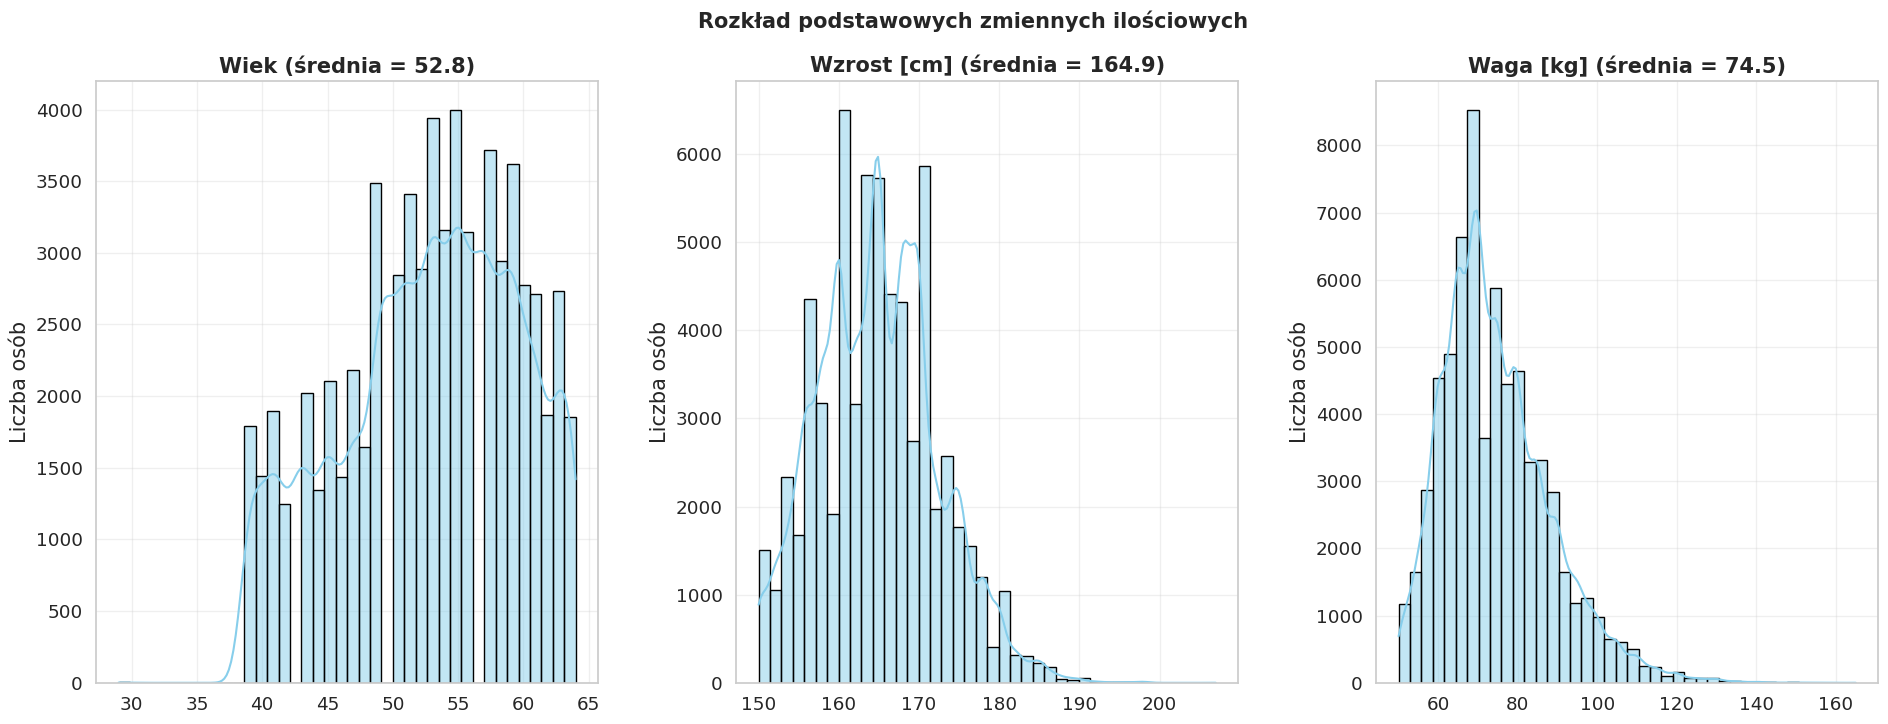

In [ ]:
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

fig, ax = plt.subplots(1, 3, figsize=(20, 8))
plt.tight_layout(pad=4.0, w_pad=4.0)

zmienne = [
    ('age', 'Wiek (średnia = {:.1f})'),
    ('height', 'Wzrost [cm] (średnia = {:.1f})'),
    ('weight', 'Waga [kg] (średnia = {:.1f})'),
]

for i, (col, title) in enumerate(zmienne):
    sns.histplot(
        df[col], bins=40, kde=True, ax=ax[i],
        color="skyblue", edgecolor="black", linewidth=1
    )

    ax[i].set_title(title.format(df[col].mean()), fontsize=15, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Liczba osób', fontsize=15)
    ax[i].grid(True, alpha=0.3)

plt.suptitle('Rozkład podstawowych zmiennych ilościowych', fontsize=15, fontweight='bold')
plt.show()


In [ ]:
#PRACA

Krzywa pojawiająca się na histogramach to krzywa gęstości (KDE — Kernel Density Estimate)
czyli estymacja płynnego rozkładu prawdopodobieństwa na podstawie danych. Pokazuje ona jak wyglądałby rozkład, gdyby był ciągły i wygładzony

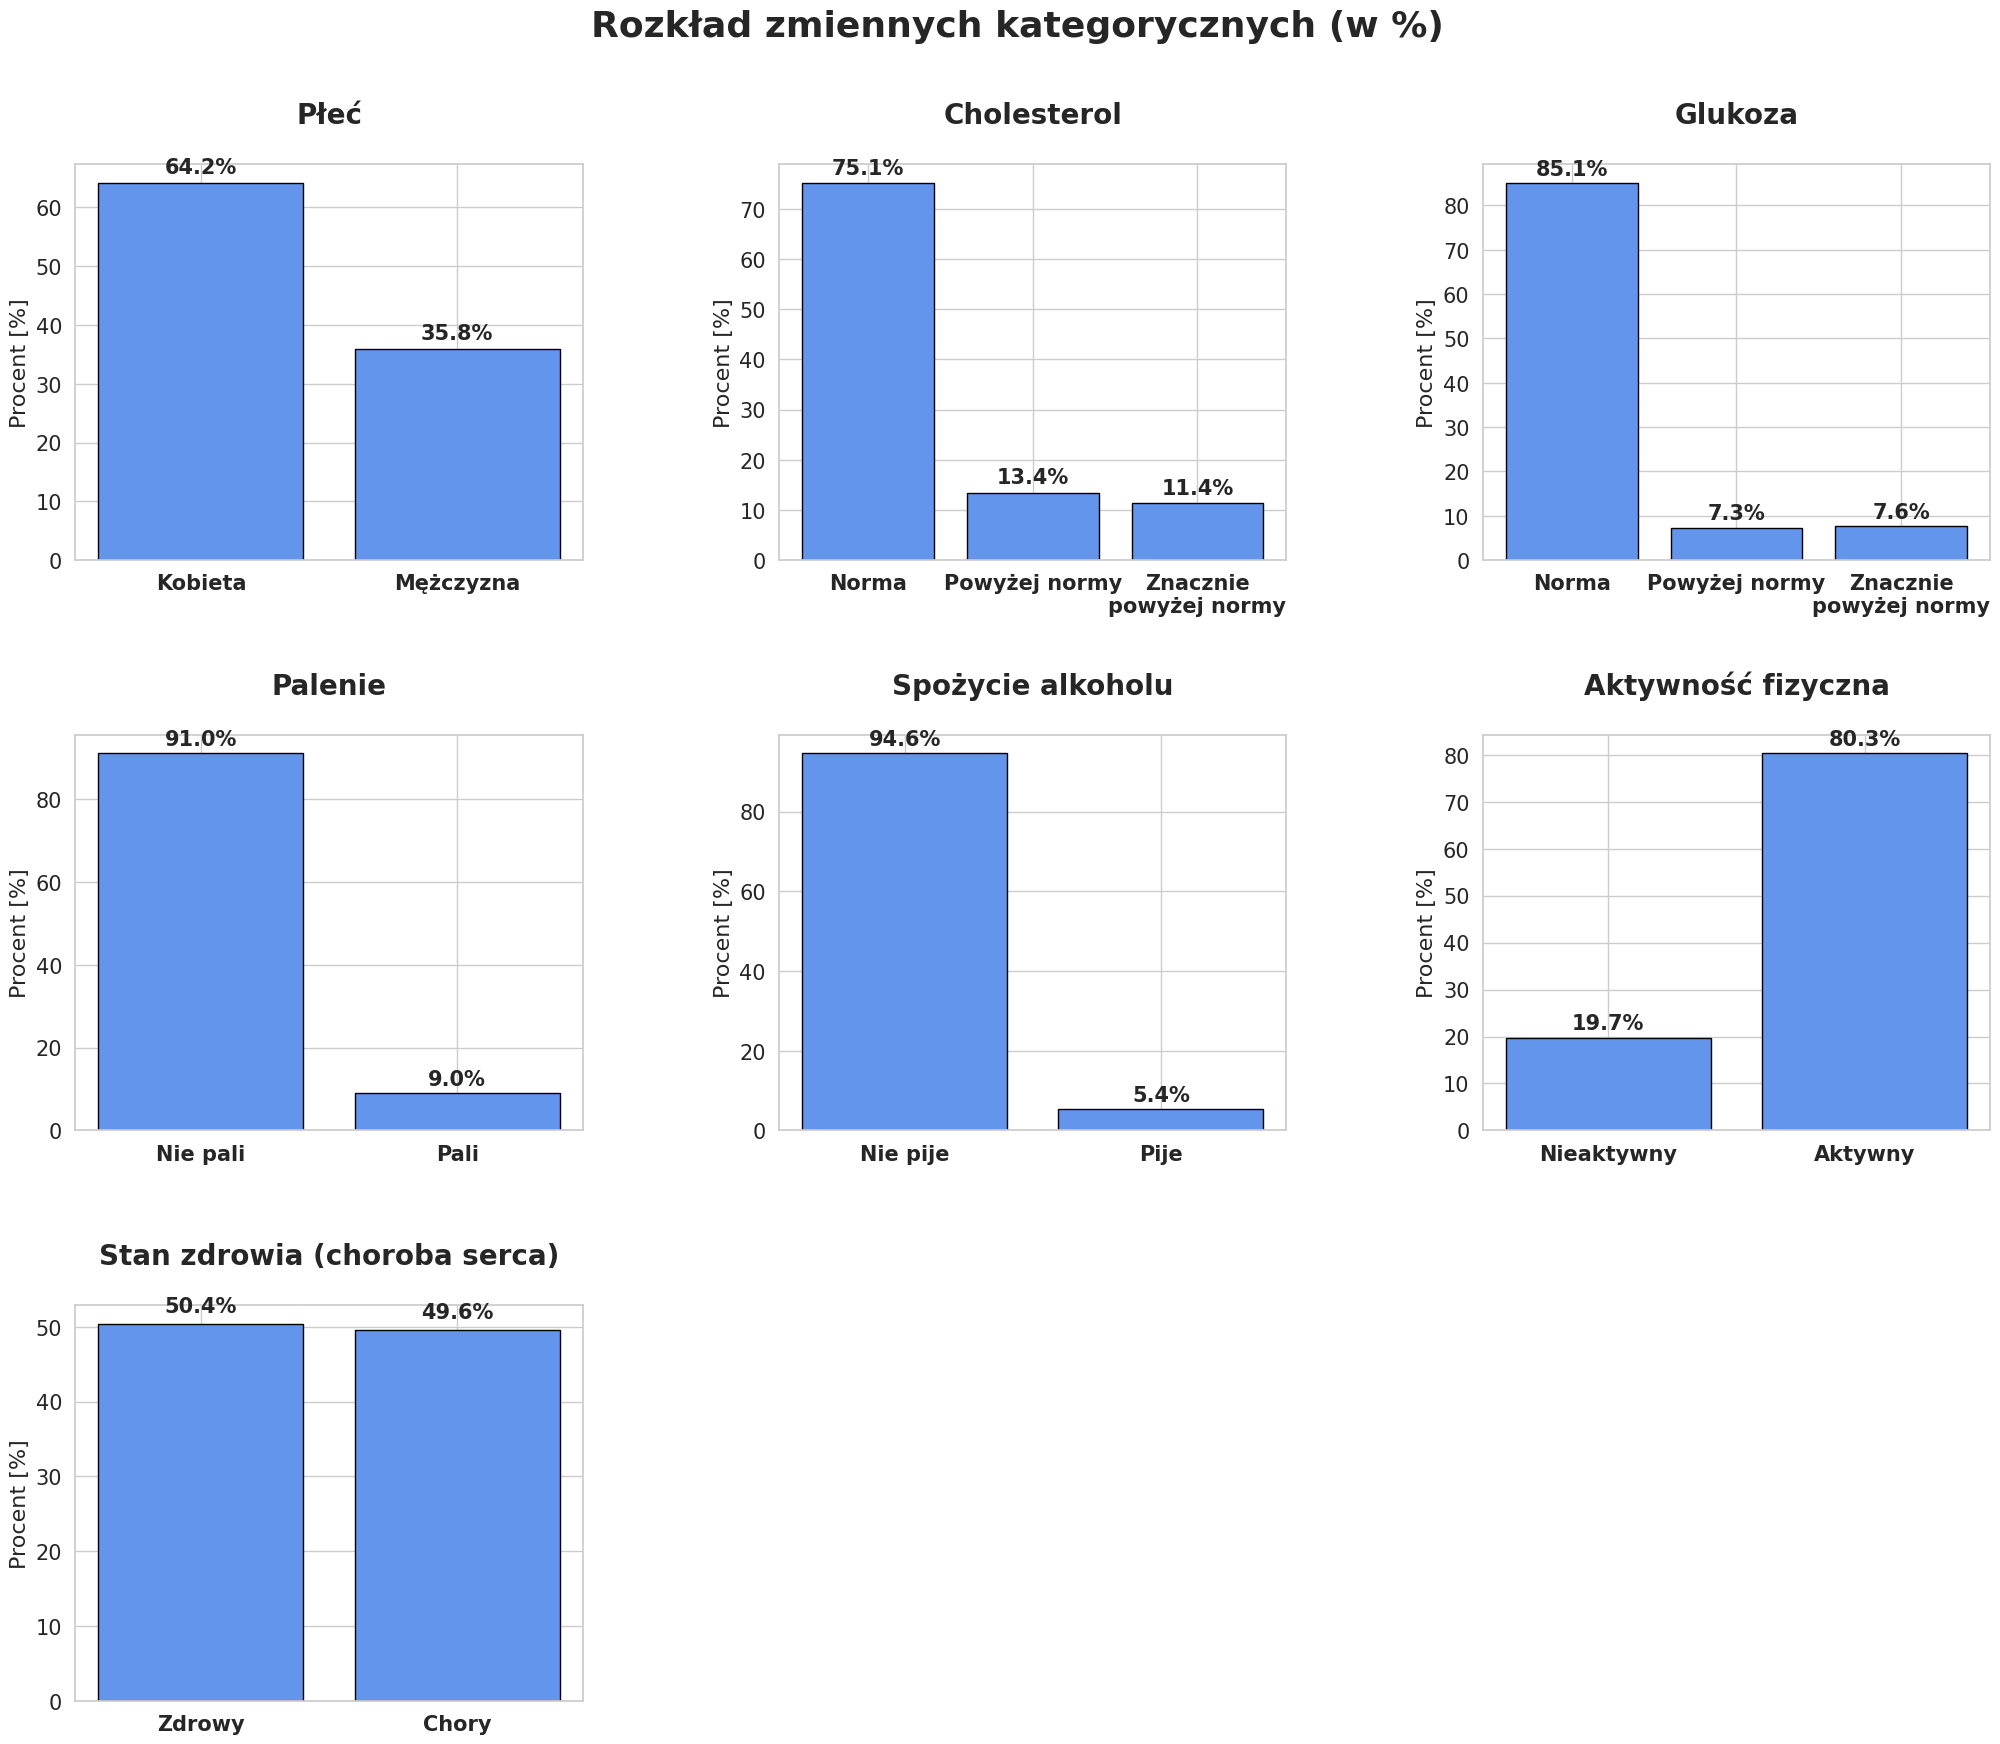

In [ ]:
import matplotlib.pyplot as plt

# Polskie tytuły wykresów (spójne nazewnictwo)
polskie_nazwy = {
    'gender': 'Płeć\n',
    'cholesterol': 'Cholesterol\n',
    'gluc': 'Glukoza\n',
    'smoke': 'Palenie\n',
    'alco': 'Spożycie alkoholu\n',
    'active': 'Aktywność fizyczna\n',
    'cardio': 'Stan zdrowia (choroba serca)\n'
}

# Polskie etykiety kategorii
etykiety = {
    'gender': ['Kobieta', 'Mężczyzna'],
    'cholesterol': ['Norma', 'Powyżej normy', 'Znacznie\npowyżej normy'],
    'gluc': ['Norma', 'Powyżej normy', 'Znacznie\npowyżej normy'],
    'smoke': ['Nie pali', 'Pali'],
    'alco': ['Nie pije', 'Pije'],
    'active': ['Nieaktywny', 'Aktywny'],
    'cardio': ['Zdrowy', 'Chory']
}

# Lista kolumn do pokazania
cols = list(polskie_nazwy.keys())

# Globalne ustawienia czcionek
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

# Siatka wykresów
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
axes = axes.flatten()
plt.tight_layout(pad=5.0, h_pad=6.0, w_pad=6.0)

for i, col in enumerate(cols):
    data = df[col].value_counts(normalize=True).sort_index() * 100
    bars = axes[i].bar(range(len(data)), data, color='cornflowerblue', edgecolor='black')

    axes[i].set_title(polskie_nazwy[col], fontsize=20, fontweight='bold')
    axes[i].set_ylabel('Procent [%]', fontsize=16)
    axes[i].set_xticks(range(len(data)))
    axes[i].set_xticklabels(etykiety[col], rotation=0, fontsize=15, fontweight='bold')

    # Etykiety procentowe nad słupkami (POWIĘKSZONE)
    for bar, val in zip(bars, data):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            val + 1,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=15,
            fontweight='bold'
        )

# Usunięcie pustych subplotów
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Rozkład zmiennych kategorycznych (w %)', fontsize=26, fontweight='bold',y=1.02)
plt.show()


In [ ]:
#PRACA

In [ ]:
#Weryfikacja hipotez statystycznych
group_0 = df[df['cardio']==0] #osoby niechore
group_1 = df[df['cardio']==1] #osoby chore

#sprawdzenie liczebności grup
print(len(group_0), len(group_1))


33374 32857


In [ ]:
# test t-Studenta

t_test,p_value = stats.ttest_ind(group_0['age'], group_1['age'], equal_var=False)
print(t_test)
print(p_value)

-62.65824383351812
0.0


Z powyższego outputu możemy wnioskować, że osoby z chorobą serca mają istotnie inny średni wiek niż osoby bez choroby serca, co oznacza, że różnica średnich wieków jest statystycznie istotna. Co potwierdzam w poniżej:

In [ ]:
print("Średni wiek bez choroby:", group_0['age'].mean())
print("Średni wiek z chorobą:", group_1['age'].mean())

Średni wiek bez choroby: 51.18067957092347
Średni wiek z chorobą: 54.375232066226374


Wykonanie testu t-Studenta dla kategorii:weight, ap_hi, ap_lo, BMI. Umieszczenie ich w jednej porównawczej tabeli:

In [ ]:
import pandas as pd
from scipy import stats

# (Tutaj Twój kod wczytujący dane i tworzący grupy...)
# Zakładam, że df jest wczytane

variables = ['age', 'ap_hi','ap_lo','weight', 'BMI']
group_0 = df[df['cardio']==0]
group_1 = df[df['cardio']==1]

group_0_m = df[(df['cardio']==0) & (df['gender']==2)]
group_1_m = df[(df['cardio']==1) & (df['gender']==2)]

group_0_k = df[(df['cardio']==0) & (df['gender']==1)]
group_1_k = df[(df['cardio']==1) & (df['gender']==1)]

results_cardio = []
results_m = []
results_k = []
stats.ttest_ind(
    group_0[var].dropna(),
    group_1[var].dropna(),
    equal_var=False
)

# Pętla 1 (Ogółem)
for var in variables:
    t_test, p_value = stats.ttest_ind(group_0[var], group_1[var], equal_var=False)
    results_cardio.append({
        'Zmienna': var,
        'Średnia bez choroby': round(group_0[var].mean(), 2), # Zaokrąglamy TU
        'Średnia z chorobą': round(group_1[var].mean(), 2),   # Zaokrąglamy TU
        'T-test': round(t_test, 2),                           # Zaokrąglamy TU
        'P-value': p_value
    })

# Pętla 2 (Mężczyźni)
for i in variables:
    t_test, p_value = stats.ttest_ind(group_0_m[i], group_1_m[i], equal_var=False)
    results_m.append({
        'Zmienna': i,
        'Średnia bez choroby': round(group_0_m[i].mean(), 2),
        'Średnia z chorobą': round(group_1_m[i].mean(), 2),
        'T-test': round(t_test, 2),
        'P-value': p_value
    })

# Pętla 3 (Kobiety)
for i in variables:
    t_test, p_value = stats.ttest_ind(group_0_k[i], group_1_k[i], equal_var=False)
    results_k.append({
        'Zmienna': i,
        'Średnia bez choroby': round(group_0_k[i].mean(), 2),
        'Średnia z chorobą': round(group_1_k[i].mean(), 2),
        'T-test': round(t_test, 2),
        'P-value': p_value
    })

results_cardio_df = pd.DataFrame(results_cardio)
results_m_df = pd.DataFrame(results_m)
results_k_df = pd.DataFrame(results_k)

# Formatowanie P-value (żeby nie było 0.0)
# Używamy formatowania stringa, żeby zawsze pokazało "< 0.001" lub 4 miejsca po przecinku
def format_p(x):
    if x < 0.001:
        return "0.0001"
    else:
        return f"{x:.4f}"

results_cardio_df['P-value'] = results_cardio_df['P-value'].apply(format_p)
results_m_df['P-value'] = results_m_df['P-value'].apply(format_p)
results_k_df['P-value'] = results_k_df['P-value'].apply(format_p)

# WYPISYWANIE (Już BEZ .round(2) na końcu!)
print('\n --- Test t-Studenta dla kobiet i mężczyzn ---\n')
print(results_cardio_df.to_string(index=False))

print('\n --- Test t-Studenta dla mężczyzn ---\n')
print(results_m_df.to_string(index=False))

print('\n --- Test t-Studenta dla kobiet ---\n')
print(results_k_df.to_string(index=False))


 --- Test t-Studenta dla kobiet i mężczyzn ---

Zmienna  Średnia bez choroby  Średnia z chorobą  T-test P-value
    age                51.18              54.38  -62.66  0.0001
  ap_hi               119.76             133.84 -120.90  0.0001
  ap_lo                78.23              84.54  -92.18  0.0001
 weight                72.13              76.93  -46.18  0.0001
    BMI                26.52              28.36  -49.01  0.0001

 --- Test t-Studenta dla mężczyzn ---

Zmienna  Średnia bez choroby  Średnia z chorobą  T-test P-value
    age                51.10              54.03  -33.27  0.0001
  ap_hi               121.18             135.06  -71.56  0.0001
  ap_lo                79.13              85.24  -54.11  0.0001
 weight                74.74              79.72  -28.52  0.0001
    BMI                25.81              27.47  -30.96  0.0001

 --- Test t-Studenta dla kobiet ---

Zmienna  Średnia bez choroby  Średnia z chorobą  T-test P-value
    age                51.22             

In [ ]:
import pandas as pd

# --- 1. RESET DANYCH (KLUCZOWE DLA NAPRAWY BŁĘDU) ---
# Odtwarzamy DataFrame'y z list, aby P-value znów było liczbą, a nie tekstem
results_cardio_df = pd.DataFrame(results_cardio)
results_m_df = pd.DataFrame(results_m)
results_k_df = pd.DataFrame(results_k)

# --- 2. FUNKCJE POMOCNICZE ---

# Funkcja do formatowania p-value (na tekst)
def format_p_value(val):
    if val < 0.001:
        return "< 0.001"
    else:
        return f"{val:.4f}"

# Funkcja przygotowująca pojedynczy blok danych
def prepare_df(df):
    # Kopia, żeby nie mieszać w oryginale
    df = df.copy()

    # Formatujemy p-value na tekst (teraz zadziała, bo val to liczba)
    df['P-value'] = df['P-value'].apply(format_p_value)

    # Zaokrąglamy resztę kolumn liczbowych
    # Upewniamy się, że kolumny istnieją w df (T-test vs T-test)
    cols_to_round = ['Średnia bez choroby', 'Średnia z chorobą', 'T-test']

    # Zabezpieczenie na wypadek gdyby nazwy kolumn były inne
    existing_cols = [c for c in cols_to_round if c in df.columns]
    df[existing_cols] = df[existing_cols].round(2)

    # Zmieniamy nazwy kolumn na ładniejsze do tabeli
    df = df.rename(columns={
        'Średnia bez choroby': 'Średnia (Zdrowi)',
        'Średnia z chorobą': 'Średnia (Chorzy)',
        'T-test': 't',
        'P-value': 'p'
    })

    # Wybieramy tylko potrzebne kolumny
    return df[['Zmienna', 'Średnia (Zdrowi)', 'Średnia (Chorzy)', 't', 'p']]

# --- 3. ŁĄCZENIE I GENEROWANIE LATEX ---

# Łączenie z wykorzystaniem kluczy (keys) - tworzy nagłówki grup
final_df = pd.concat([
    prepare_df(results_cardio_df),
    prepare_df(results_m_df),
    prepare_df(results_k_df)
], keys=['Kobiety i mężczyźni', 'Mężczyźni', 'Kobiety'])

# Generowanie kodu LaTeX
latex_table = final_df.to_latex(
    index=True,          # Włączamy indeks (grupy)
    multirow=True,       # Łączy nazwę grupy w jedną komórkę
    caption='Wyniki testu t-Studenta dla wybranych cech z podziałem na grupy',
    label='tab:ttest_full_names',
    column_format='llrrrr', # Formatowanie kolumn
    escape=False         # Pozwala na znaki specjalne (np. <)
)

# Kosmetyka: zamiana pustego nagłówka indeksu na "Grupa"
latex_table = latex_table.replace('{} &', 'Grupa &')

print(latex_table)

\begin{table}
\caption{Wyniki testu t-Studenta dla wybranych cech z podziałem na grupy}
\label{tab:ttest_full_names}
\begin{tabular}{llrrrr}
\toprule
 &  & Zmienna & Średnia (Zdrowi) & Średnia (Chorzy) & t & p \\
\midrule
\multirow[t]{5}{*}{Kobiety i mężczyźni} & 0 & age & 51.180000 & 54.380000 & -62.660000 & < 0.001 \\
 & 1 & ap_hi & 119.760000 & 133.840000 & -120.900000 & < 0.001 \\
 & 2 & ap_lo & 78.230000 & 84.540000 & -92.180000 & < 0.001 \\
 & 3 & weight & 72.130000 & 76.930000 & -46.180000 & < 0.001 \\
 & 4 & BMI & 26.520000 & 28.360000 & -49.010000 & < 0.001 \\
\cline{1-7}
\multirow[t]{5}{*}{Mężczyźni} & 0 & age & 51.100000 & 54.030000 & -33.270000 & < 0.001 \\
 & 1 & ap_hi & 121.180000 & 135.060000 & -71.560000 & < 0.001 \\
 & 2 & ap_lo & 79.130000 & 85.240000 & -54.110000 & < 0.001 \\
 & 3 & weight & 74.740000 & 79.720000 & -28.520000 & < 0.001 \\
 & 4 & BMI & 25.810000 & 27.470000 & -30.960000 & < 0.001 \\
\cline{1-7}
\multirow[t]{5}{*}{Kobiety} & 0 & age & 51.220000 & 54.57

In [ ]:
latex_table = final_df.to_latex(
    index=False,
    caption='Wyniki testu t-Studenta dla wybranych cech w podziale na płeć',
    label='tab:ttest_vertical',
    column_format='llrrr',
    float_format='%.2f',
    escape=False
)

print(latex_table)


\begin{table}
\caption{Wyniki testu t-Studenta dla wybranych cech w podziale na płeć}
\label{tab:ttest_vertical}
\begin{tabular}{llrrr}
\toprule
Grupa & Zmienna & Bez choroby & Z chorobą & t \\
\midrule
Kobiety i mężczyźni & age & 51.18 & 54.38 & -62.66 \\
Kobiety i mężczyźni & ap_hi & 119.76 & 133.84 & -120.90 \\
Kobiety i mężczyźni & ap_lo & 78.23 & 84.54 & -92.18 \\
Kobiety i mężczyźni & weight & 72.13 & 76.93 & -46.18 \\
Kobiety i mężczyźni & BMI & 26.52 & 28.36 & -49.01 \\
Mężczyźni & age & 51.10 & 54.03 & -33.27 \\
Mężczyźni & ap_hi & 121.18 & 135.06 & -71.56 \\
Mężczyźni & ap_lo & 79.13 & 85.24 & -54.11 \\
Mężczyźni & weight & 74.74 & 79.72 & -28.52 \\
Mężczyźni & BMI & 25.81 & 27.47 & -30.96 \\
Kobiety & age & 51.22 & 54.57 & -53.64 \\
Kobiety & ap_hi & 118.98 & 133.16 & -97.67 \\
Kobiety & ap_lo & 77.74 & 84.14 & -74.79 \\
Kobiety & weight & 70.69 & 75.35 & -36.68 \\
Kobiety & BMI & 26.90 & 28.87 & -39.27 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
#PRACA do 2 miejsc po przecinku

In [ ]:
p_value

np.float64(0.0)

Osoby chore (zarówno kobiety, jak i mężczyźni) mają wyższe średnie wartości wieku, ciśnienia skurczowego i rozkurczowego, masy ciała oraz BMI niż osoby zdrowe w tych samych grupach płci.
Wszystkie różnice pomiędzy grupami są bardzo istotne statystycznie (p-value praktycznie 0), co wskazuje na silny związek tych cech z chorobą.
Otyłość i podwyższone ciśnienie oraz wiek mogą być kluczowymi czynnikami ryzyka zarówno u kobiet, jak i u mężczyzn

Podsumowywując te same cechy ryzyka (wiek, ciśnienie, waga, BMI) są istotnie związane z chorobą tak u kobiet, jak i u mężczyzn.



Przeprowadzam test istotności dla współczynnika korelacji Pearsona

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# --- DANE ---
# (Zakładam, że df jest wczytane)
cols = ['age', 'BMI', 'ap_hi', 'ap_lo', 'weight']
corr_results = []

# --- OBLICZENIA ---
# Używamy pętli, żeby uniknąć duplikatów (A-B to to samo co B-A)
# i przekątnej (A-A)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1 = cols[i]
        c2 = cols[j]

        # Obliczamy korelację i p-value
        corr, p = pearsonr(df[c1], df[c2])

        # Formatowanie p-value do ładnego tekstu
        if p < 0.001:
            p_text = "< 0.001"
        else:
            p_text = f"{p:.4f}"

        corr_results.append({
            'Zmienna 1': c1,
            'Zmienna 2': c2,
            'Korelacja (r)': round(corr, 4),
            'P-value': p_text,
            'Istotne?': 'TAK' if p < 0.05 else 'NIE'
        })

# --- WYNIK ---
corr_df = pd.DataFrame(corr_results)

# Sortujemy od najsilniejszej korelacji (moduł), żeby było ciekawiej
corr_df['Abs_Corr'] = corr_df['Korelacja (r)'].abs()
corr_df = corr_df.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr'])

print(corr_df.to_string(index=False))

# --- GENEROWANIE TABELI LATEX (opcjonalnie) ---
print("\n--- KOD LATEX ---\n")
print(corr_df.to_latex(index=False, caption='Wyniki analizy korelacji Pearsona wraz z istotnością statystyczną', label='tab:corr_results'))

Zmienna 1 Zmienna 2  Korelacja (r) P-value Istotne?
      BMI    weight         0.8687 < 0.001      TAK
    ap_hi     ap_lo         0.7311 < 0.001      TAK
    ap_hi    weight         0.2645 < 0.001      TAK
      BMI     ap_hi         0.2608 < 0.001      TAK
    ap_lo    weight         0.2458 < 0.001      TAK
      BMI     ap_lo         0.2337 < 0.001      TAK
      age     ap_hi         0.2042 < 0.001      TAK
      age     ap_lo         0.1522 < 0.001      TAK
      age       BMI         0.0998 < 0.001      TAK
      age    weight         0.0561 < 0.001      TAK

--- KOD LATEX ---

\begin{table}
\caption{Wyniki analizy korelacji Pearsona wraz z istotnością statystyczną}
\label{tab:corr_results}
\begin{tabular}{llrll}
\toprule
Zmienna 1 & Zmienna 2 & Korelacja (r) & P-value & Istotne? \\
\midrule
BMI & weight & 0.868700 & < 0.001 & TAK \\
ap_hi & ap_lo & 0.731100 & < 0.001 & TAK \\
ap_hi & weight & 0.264500 & < 0.001 & TAK \\
BMI & ap_hi & 0.260800 & < 0.001 & TAK \\
ap_lo & weight &

Analiza korelacji wykazała, że wartości ciśnienia tętniczego (zarówno skurczowego, jak i rozkurczowego) są dodatnio powiązane z wiekiem oraz wskaźnikami masy ciała (waga, BMI).
Szczególnie silny związek występuje między BMI a wagą (r = 0.85) oraz między ciśnieniem skurczowym i rozkurczowym (r = 0.73).
Oznacza to, że osoby starsze i z nadwagą mają przeciętnie wyższe ciśnienie tętnicze, co potwierdza znane zależności fizjologiczne i epidemiologiczne.

Teraz przechodzimy do korealcji i heatmapy

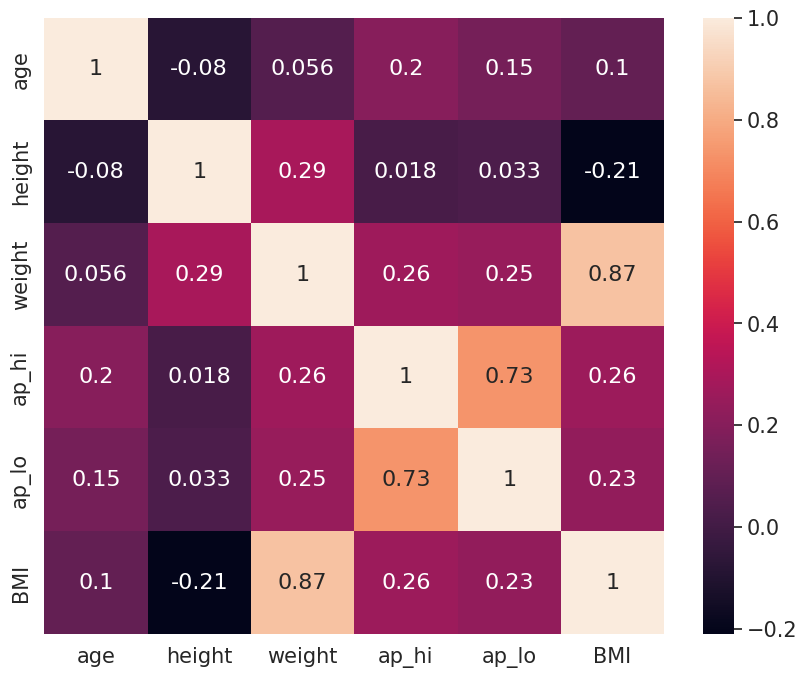

In [ ]:
corr = df[['age','height','weight','ap_hi','ap_lo','BMI']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()


In [ ]:
#PRACA

NameError: name 'n' is not defined

Analiza korelacji wykazała silne i oczekiwane zależności między masą ciała a wskaźnikiem BMI (r = 0.76) oraz pomiędzy wartościami ciśnienia skurczowego i rozkurczowego (r = 0.71). Obserwowane umiarkowane dodatnie korelacje między masą ciała, BMI oraz wartościami ciśnienia wskazują, że nadwaga może być czynnikiem sprzyjającym nadciśnieniu??????
.


In [ ]:
chi2_s, p, dof, expected = chi2_contingency(pd.crosstab(df['cardio'], df['smoke']))
print(f"Test Chi2 dla cardio vs smoke: p={p:.4f}")
chi2alco, p, dof_alc, expected_alc = chi2_contingency(pd.crosstab(df['cardio'], df['alco']))
print(f"Test Chi2 dla cardio vs alco: p={p:.4f}")
chi2_act, p, dof_act, expected_act = chi2_contingency(pd.crosstab(df['cardio'], df['active']))
print(f"Test Chi2 dla cardio vs active: p={p:.4f}")

Test Chi2 dla cardio vs smoke: p=0.0000
Test Chi2 dla cardio vs alco: p=0.0226
Test Chi2 dla cardio vs active: p=0.0000


Przeprowadzony test niezależności χ² wykazał istotne statystycznie zależności między występowaniem chorób układu sercowo-naczyniowego a czynnikami stylu życia, takimi jak palenie tytoniu (p < 0.001), spożywanie alkoholu (p = 0.031) oraz poziom aktywności fizycznej (p < 0.001). Wyniki te sugerują, że osoby palące, spożywające alkohol oraz prowadzące siedzący tryb życia charakteryzują się wyższym ryzykiem występowania chorób serca. Otrzymane zależności są zgodne z aktualną wiedzą medyczną dotyczącą wpływu zachowań zdrowotnych na funkcjonowanie układu krążenia.

Powyższe wyniki przedstawiono poniżej w formie graficznej

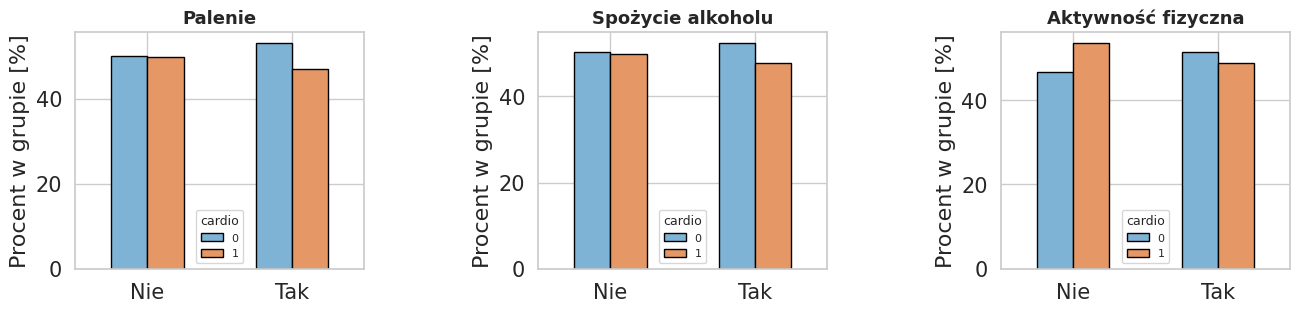

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Lista zmiennych stylu życia
vars = ['smoke', 'alco', 'active']
labels_pl = {
    'smoke': 'Palenie',
    'alco': 'Spożycie alkoholu',
    'active': 'Aktywność fizyczna'
}

fig, axes = plt.subplots(1, 3, figsize=(15,5))
plt.tight_layout(pad=5.0)

for i, var in enumerate(vars):
    cross = pd.crosstab(df[var], df['cardio'], normalize='index') * 100
    cross.columns = ['0', '1']

    cross.plot(kind='bar', ax=axes[i], color=['#7FB3D5', '#E59866'], edgecolor='black')

    axes[i].set_title(labels_pl[var], fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Procent w grupie [%]')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Nie', 'Tak'], rotation=0)
    axes[i].legend(title='cardio', loc='lower center', fontsize=8, title_fontsize=9)


plt.show()


In [ ]:
#PRACA

Tworzymy FOREST PLOT (wykres efektów regresji), który pozwala nam określić czy dana zmienna ma faktycznie znaczenie w przypadku wystąpienia choroby czy też nie.

Optimization terminated successfully.
         Current function value: 0.561745
         Iterations 6


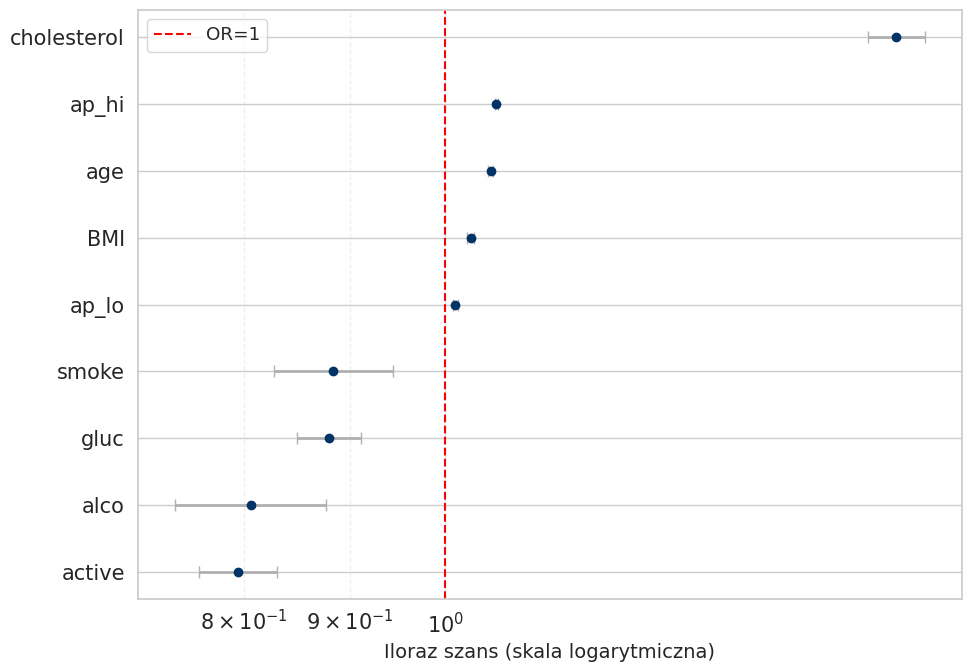

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. PRZYGOTOWANIE DANYCH I MODELU ---
# Zakładam, że masz już wczytany DataFrame jako 'df'
# X = zmienne objaśniające
X = df[['age', 'BMI', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']]
y = df['cardio']

# Dodanie stałej (intercept) - wymagane w statsmodels
X = sm.add_constant(X)

# Dopasowanie modelu
model = sm.Logit(y, X).fit()

# --- 2. OBLICZENIA WYNIKÓW (OR i CI) ---
# Tworzymy tabelę ze współczynnikami i przedziałami ufności
results = pd.DataFrame({
    'Zmienna': model.params.index,
    'Współczynnik': model.params.values,
    'Dolny przedział 95%': model.conf_int()[0],
    'Górny przedział 95%': model.conf_int()[1]
})

# Obliczamy iloraz szans (OR - Odds Ratio)
results['OR'] = np.exp(results['Współczynnik'])
results['OR_lower'] = np.exp(results['Dolny przedział 95%'])
results['OR_upper'] = np.exp(results['Górny przedział 95%'])

# Usuwamy stałą (const) z wykresu, bo nie jest interpretowalna jako ryzyko
results = results[results['Zmienna'] != 'const']

# --- 3. PRZYGOTOWANIE DO WYKRESU ---

# Ustawiamy etykiety tak jak w danych (ap_hi, gluc, etc.)
results['Etykieta'] = results['Zmienna']

# Sortowanie wyników rosnąco po OR dla czytelności wykresu
results = results.sort_values('OR', ascending=True)

# --- 4. RYSOWANIE WYKRESU ---
plt.figure(figsize=(10, 7))

# Rysowanie punktów i błędów (Error Bars)
plt.errorbar(
    results['OR'],
    results['Etykieta'],
    xerr=[results['OR'] - results['OR_lower'], results['OR_upper'] - results['OR']],
    fmt='o',               # Kropka jako znacznik
    color='#003366',       # Ciemniejszy granat
    ecolor='#B0B0B0',      # Szare linie błędu
    elinewidth=2,          # Grubość linii błędu
    capsize=4,             # Rozmiar "daszków" na końcach linii
    markersize=6           # Rozmiar kropki
)

plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='OR=1')

ax = plt.gca()
ax.set_xscale('log')

ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())

plt.grid(True, which="both", axis='x', linestyle='--', alpha=0.3)
plt.grid(True, which="major", axis='x', linestyle='--', alpha=0.6)

plt.xlabel('Iloraz szans (skala logarytmiczna)', fontsize=14)

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
#PRACA

Na rysunku przedstawiono ilorazy szans (OR) dla zmiennych w modelu regresji logistycznej. Wiek, ciśnienie tętnicze (skurczowe i rozkurczowe), BMI oraz poziom cholesterolu istotnie zwiększają ryzyko wystąpienia chorób układu sercowo-naczyniowego (OR > 1). Aktywność fizyczna wykazuje efekt ochronny (OR < 1). Pozostałe zmienne, takie jak glukoza, palenie i spożycie alkoholu, charakteryzują się słabszym lub odwrotnym wpływem, co może wynikać z efektu współzmiennych (np. młodszy wiek osób palących), a nie z rzeczywistego działania tych czynników ochronnych.

Punkty (kółka) to wartości ilorazu szans (OR) — czyli, o ile wzrasta (lub maleje) ryzyko choroby.

Linie poziome to 95% przedziały ufności.

Czerwona linia pionowa (OR = 1) oznacza brak wpływu na ryzyko wystąpienia choroby.

OR > 1 → zwiększa ryzyko choroby,

OR < 1 → zmniejsza ryzyko

VIOLINPLOT(przykłady cardio vs BMI)

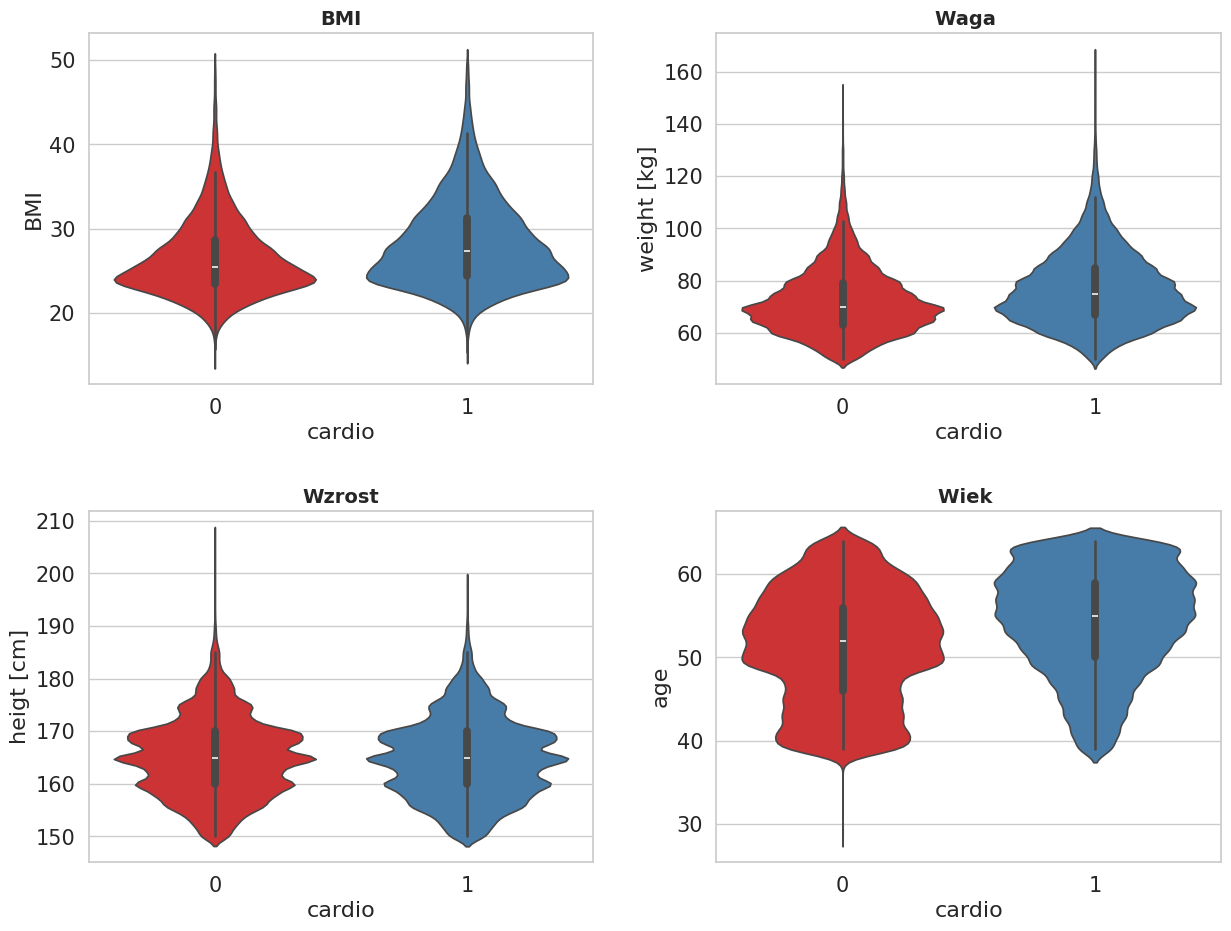

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes.flatten()

sns.violinplot(x='cardio', y='BMI', hue='cardio', data=df, ax=ax[0], palette='Set1', legend=False)
ax[0].set_title('BMI', fontsize=14, fontweight='bold')
ax[0].set_xlabel('cardio')
ax[0].set_ylabel('BMI')

sns.violinplot(x='cardio', y='weight', hue='cardio', data=df, ax=ax[1], palette='Set1', legend=False)
ax[1].set_title('Waga ', fontsize=14, fontweight='bold')
ax[1].set_xlabel('cardio')
ax[1].set_ylabel('weight [kg]')

sns.violinplot(x='cardio', y='height', hue='cardio', data=df, ax=ax[2], palette='Set1', legend=False)
ax[2].set_title('Wzrost', fontsize=14, fontweight='bold')
ax[2].set_xlabel('cardio')
ax[2].set_ylabel('heigt [cm]')

sns.violinplot(x='cardio', y='age', hue='cardio', data=df, ax=ax[3], palette='Set1', legend=False)
ax[3].set_title('Wiek ', fontsize=14, fontweight='bold')
ax[3].set_xlabel('cardio')
ax[3].set_ylabel('age')

plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
#PRACA zastanowić się nad nazwami rysunków / usunąc legende

Na violinplocie linia i kropki pokazują statystyki (mediana, kwartyle),
a kształt i szerokość – pokazują rozkład danych (jak gęsto występują poszczególne wartości).

Największy wpływ na występowanie chorób serca mają wiek i wskaźnik BMI.

Wyniki są spójne z wiedzą medyczną – starsze osoby oraz te z nadwagą lub otyłością są znacznie bardziej narażone na problemy kardiologiczne.

Wzrost i masa ciała mają pewien wpływ, lecz wtórny wobec BMI

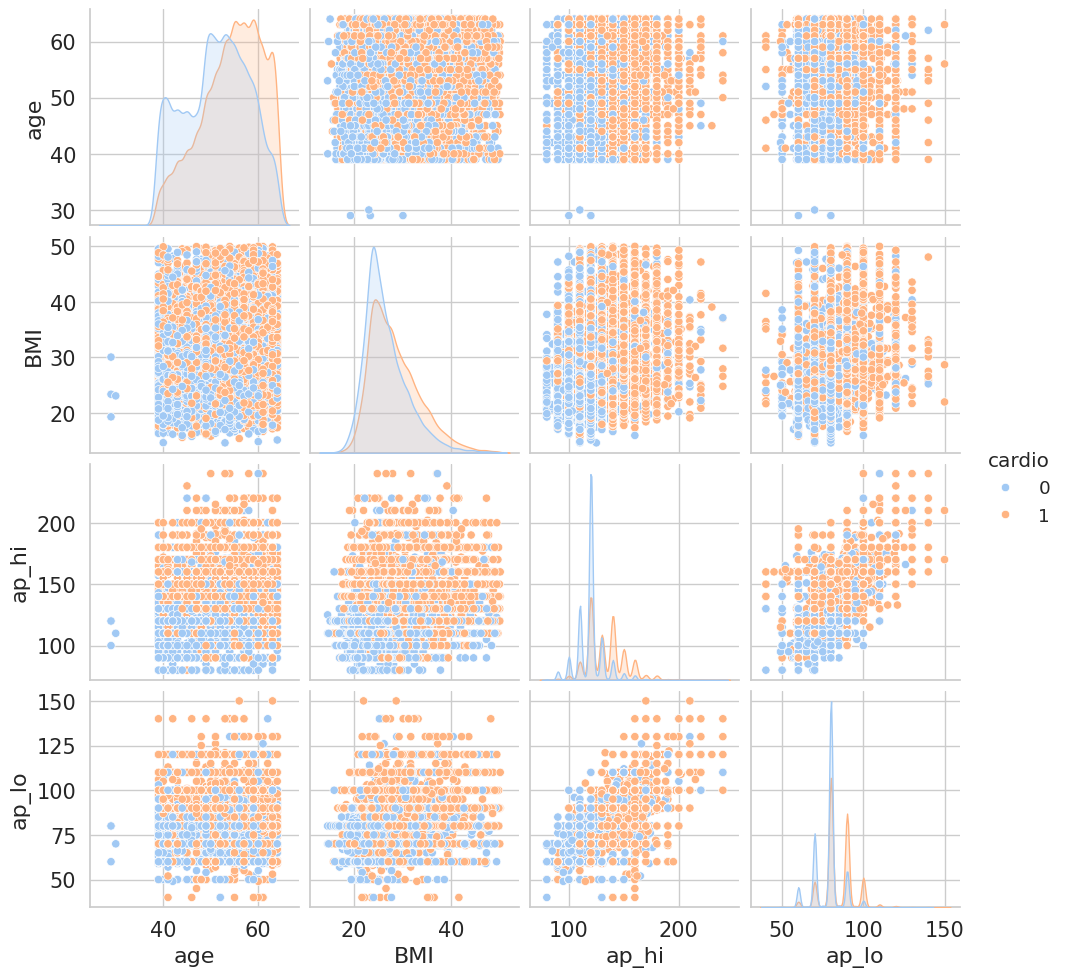

In [ ]:
sns.pairplot(df[['age','BMI','ap_hi','ap_lo','cardio']], hue='cardio')


In [ ]:
#PRACA

Analiza rozkładów i zależności par zmiennych wskazuje, że osoby z rozpoznaną chorobą serca (cardio=1) charakteryzują się wyższym wiekiem i wyższym BMI w porównaniu do osób zdrowych. Widoczna jest także większa gęstość przypadków choroby w starszych grupach wiekowych, co potwierdza silny związek wieku z ryzykiem wystąpienia chorób serca.

Przprowadzamy KLASYFIKACJĘ

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age','BMI','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#STANDARYZACJA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


RAPORT KLASYFIKACYJNY

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_pca, y_train)


y_train_pred = model.predict(X_train_pca)
y_train_proba = model.predict_proba(X_train_pca)[:, 1]


y_test_pred = model.predict(X_test_pca)
y_test_proba = model.predict_proba(X_test_pca)[:, 1]

print("\n================ TRENING ================")
print(classification_report(y_train, y_train_pred))
print(f"Accuracy (train): {accuracy_score(y_train, y_train_pred):.4f}")
print(f"AUC (train): {roc_auc_score(y_train, y_train_proba):.4f}")

print("\n================ TEST ================")
print(classification_report(y_test, y_test_pred))
print(f"Accuracy (test): {accuracy_score(y_test, y_test_pred):.4f}")
print(f"AUC (test): {roc_auc_score(y_test, y_test_proba):.4f}")



================ TRENING ================
              precision    recall  f1-score   support

           0       0.71      0.77      0.74     26618
           1       0.74      0.68      0.71     26366

    accuracy                           0.72     52984
   macro avg       0.72      0.72      0.72     52984
weighted avg       0.72      0.72      0.72     52984

Accuracy (train): 0.7231
AUC (train): 0.7821

================ TEST ================
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6756
           1       0.74      0.68      0.71      6491

    accuracy                           0.72     13247
   macro avg       0.73      0.72      0.72     13247
weighted avg       0.73      0.72      0.72     13247

Accuracy (test): 0.7248
AUC (test): 0.7823


MACIERZ POMYŁEK

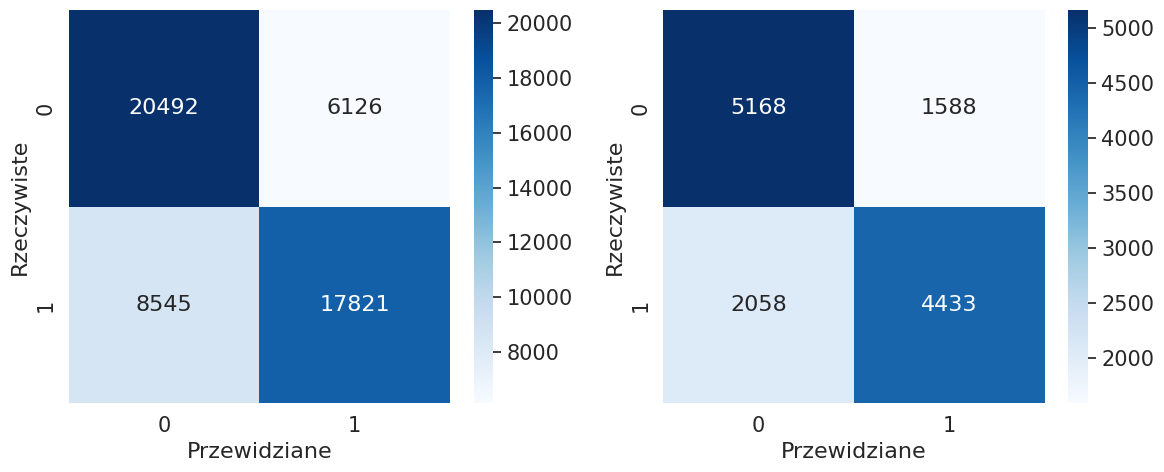

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Macierz pomyłek – zbiór treningowy
sns.heatmap(
    confusion_matrix(y_train, y_train_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_xlabel("Przewidziane")
axes[0].set_ylabel("Rzeczywiste")

# Macierz pomyłek – zbiór testowy
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)

axes[1].set_xlabel("Przewidziane")
axes[1].set_ylabel("Rzeczywiste")

plt.tight_layout()
plt.show()


In [ ]:
#PRACA

In [ ]:
train_pred = model.predict(X_train_pca)
test_pred = model.predict(X_test_pca)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

Train accuracy: 0.723105088328552
Test accuracy: 0.7247678719710123


Różnica między dokładnością na zbiorze treningowym i testowym jest minimalna.
→ To znaczy, że model dobrze generalizuje (brak overfittingu)

RYSOWANIE KRZYWĄ ROC

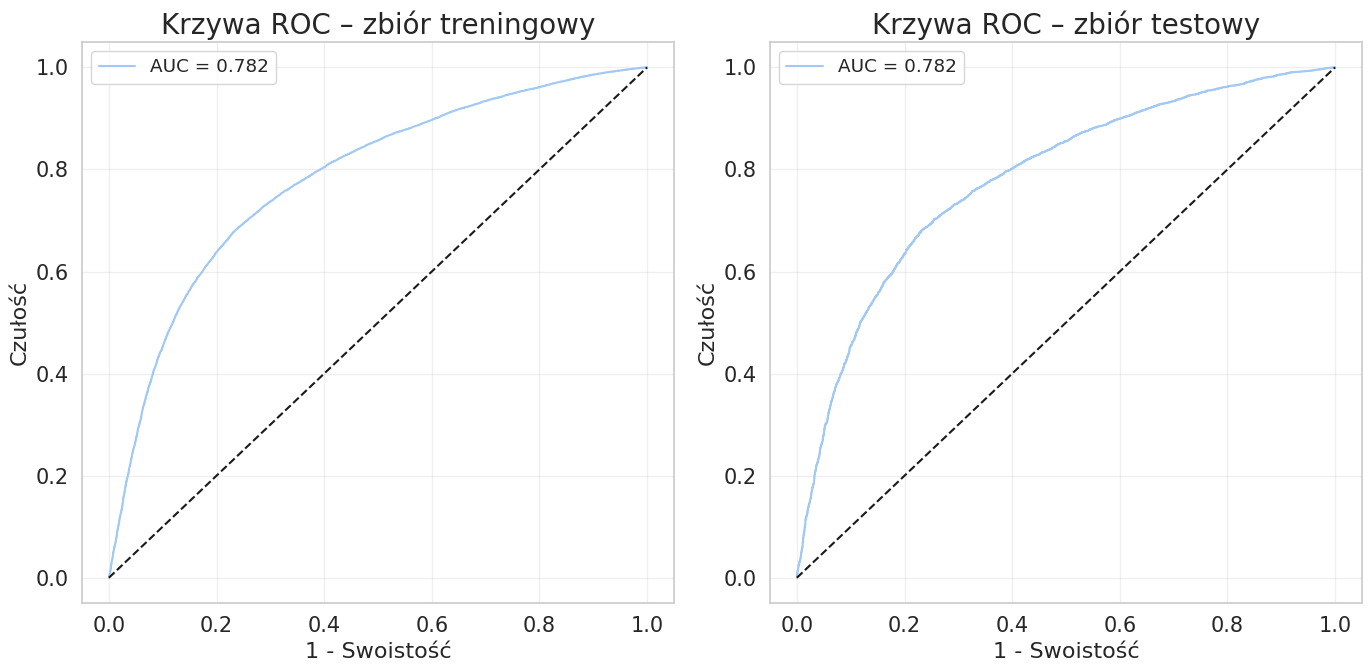

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ROC – zbiór treningowy
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
auc_train = roc_auc_score(y_train, y_train_proba)

axes[0].plot(fpr_train, tpr_train, label=f"AUC = {auc_train:.3f}")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title("Krzywa ROC – zbiór treningowy")
axes[0].set_xlabel("1 - Swoistość")
axes[0].set_ylabel("Czułość")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ROC – zbiór testowy
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

axes[1].plot(fpr_test, tpr_test, label=f"AUC = {auc_test:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title("Krzywa ROC – zbiór testowy")
axes[1].set_xlabel("1 - Swoistość")
axes[1].set_ylabel("Czułość")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier

# # 1. Definicja słownika z modelami i ich unikalnymi siatkami parametrów
# models_params = {
#     "Random Forest": {
#         "model": RandomForestClassifier(random_state=42),
#         "params": {
#             'n_estimators': [100, 300],
#             'max_depth': [10, 20, None],
#             'min_samples_split': [2, 5]
#         }
#     },
#     "SVM": {
#         "model": SVC(probability=True, random_state=42),
#         "params": {
#             'C': [0.1, 1, 10],           # Parametr regularyzacji
#             'kernel': ['rbf', 'linear'], # Typ jądra
#             'gamma': ['scale', 'auto']   # Współczynnik jądra
#         }
#     },
#     "XGBoost": {
#         "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
#         "params": {
#             'n_estimators': [100, 300],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'max_depth': [3, 5, 7]
#         }
#     }
# }

# # 2. Pętla uruchamiająca Grid Search dla każdego modelu po kolei
# best_estimators = {} # Tu zapiszemy najlepsze wersje modeli

# for name, mp in models_params.items():
#     print(f"\n🔍 Rozpoczynam Grid Search dla: {name}...")

#     clf = GridSearchCV(
#         estimator=mp['model'],
#         param_grid=mp['params'],
#         cv=5,               # 5-krotna walidacja
#         scoring='roc_auc',  # Szukamy najwyższego AUC
#         n_jobs=-1,          # Użycie wszystkich rdzeni
#         verbose=1
#     )

#     # Trenowanie (szukanie)
#     clf.fit(X_train_pca, y_train)

#     # Zapisanie wyników
#     print(f"   ✅ Najlepsze parametry: {clf.best_params_}")
#     print(f"   ✅ Najlepsze AUC (walidacja): {clf.best_score_:.4f}")

#     # Zapisujemy najlepszy model do słownika, żeby użyć go później
#     best_estimators[name] = clf.best_estimator_

# print("\n🚀 Zakończono optymalizację wszystkich modeli.")

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# from sklearn.metrics import (
#     classification_report, confusion_matrix, accuracy_score,
#     roc_curve, roc_auc_score
# )
# from xgboost import XGBClassifier

# # --- USTAWIENIA STYLU ---
# sns.set_style("whitegrid")
# plt.rcParams['figure.dpi'] = 100

# # ==========================================
# # 1. DEFINICJE FUNKCJI RYSUJĄCYCH (BEZ ZMIAN)
# # ==========================================

# def save_heatmap_report(y_true, y_pred, title, filename):
#     """Generuje heatmapę raportu klasyfikacyjnego (Precision, Recall, F1)."""
#     report_dict = classification_report(y_true, y_pred, output_dict=True)
#     acc = report_dict['accuracy']
#     df = pd.DataFrame(report_dict).transpose()

#     # Usuwamy wiersz accuracy (bo jest w tytule) i kolumnę support
#     if 'accuracy' in df.index:
#         df_plot = df.drop(['accuracy'], axis=0)
#     else:
#         df_plot = df

#     if 'support' in df_plot.columns:
#         df_plot = df_plot.drop(['support'], axis=1)

#     plt.figure(figsize=(6, 4))
#     # STYL: czcionka 14, format .3f
#     sns.heatmap(df_plot, annot=True, cmap='Blues', fmt='.3f', cbar=False, annot_kws={"size": 14})
#     plt.title(f"{title}\n(Accuracy: {acc:.4f})", fontsize=14, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# def save_confusion_matrix(y_true, y_pred, title, filename):
#     """Generuje macierz pomyłek."""
#     cm = confusion_matrix(y_true, y_pred)
#     plt.figure(figsize=(6, 4))
#     # STYL: czcionka 14, etykiety 0/1
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14},
#                 xticklabels=['0', '1'], yticklabels=['0', '1'])
#     plt.title(title, fontsize=14, fontweight='bold')
#     plt.ylabel('Rzeczywiste')
#     plt.xlabel('Przewidziane')
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# def save_roc_curve(y_true, y_proba, title, filename):
#     """Generuje krzywą ROC."""
#     fpr, tpr, _ = roc_curve(y_true, y_proba)
#     auc_val = roc_auc_score(y_true, y_proba)
#     plt.figure(figsize=(6, 4))
#     # STYL: kolor #003366, grubość linii 3
#     plt.plot(fpr, tpr, color='#003366', lw=3, label=f'AUC = {auc_val:.4f}')
#     plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
#     plt.title(title, fontsize=14, fontweight='bold')
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.legend(loc="lower right")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# # ==========================================
# # 2. TRENING MODELU XGBOOST
# # ==========================================

# print("Trenowanie modelu XGBoost...")

# # Definicja modelu (Parametry z Twoich wcześniejszych instrukcji)
# xgb_model = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=5,
#     subsample=0.9,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42
# )

# # Zakładam, że X_train_pca, y_train, X_test_pca, y_test są już wczytane
# xgb_model.fit(X_train_pca, y_train)

# # Predykcje
# y_train_pred = xgb_model.predict(X_train_pca)
# y_train_proba = xgb_model.predict_proba(X_train_pca)[:, 1]

# y_test_pred = xgb_model.predict(X_test_pca)
# y_test_proba = xgb_model.predict_proba(X_test_pca)[:, 1]

# # ==========================================
# # 3. GENEROWANIE 6 PLIKÓW
# # ==========================================

# print("Generowanie wykresów dla XGBoost...")

# # --- 1. Heatmapy (Raporty) ---
# save_heatmap_report(y_train, y_train_pred, "XGBoost - Raport klasyfikacyjny", "XGB_heatmap_train.png")
# save_heatmap_report(y_test, y_test_pred, "XGBoost - Raport klasyfikacyjny", "XGB_heatmap_test.png")

# # --- 2. Macierze pomyłek ---
# save_confusion_matrix(y_train, y_train_pred, "XGBoost - Macierz pomyłek", "XGB_cm_train.png")
# save_confusion_matrix(y_test, y_test_pred, "XGBoost - Macierz pomyłek", "XGB_cm_test.png")

# # --- 3. Krzywe ROC ---
# save_roc_curve(y_train, y_train_proba, "XGBoost - Krzywa ROC", "XGB_roc_train.png")
# save_roc_curve(y_test, y_test_proba, "XGBoost - Krzywa ROC", "XGB_roc_test.png")

# print("✅ Gotowe! Zapisano 6 plików dla XGBoost:")
# print("   - XGB_heatmap_train.png, XGB_heatmap_test.png")
# print("   - XGB_cm_train.png, XGB_cm_test.png")
# print("   - XGB_roc_train.png, XGB_roc_test.png")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age','BMI','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#STANDARYZACJA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [ ]:
# 1. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Standaryzacja
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)


# 3. Trening modelu
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)


y_test_pred = xgb_model.predict(X_test_scaled)
y_test_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Tworzymy model z Twoimi parametrami (tymi z pracy)
xgb_model_cv = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Uruchamiamy 5-krotną walidację krzyżową na zbiorze treningowym
# scoring='roc_auc' - bo to Twoja główna metryka
cv_scores = cross_val_score(xgb_model_cv, X_train_scaled, y_train, cv=5, scoring='roc_auc')

# 3. Wypisujemy wyniki
print("Wyniki AUC dla 5 foldów:", cv_scores)
print(f"Średnia AUC: {np.mean(cv_scores):.4f}")
print(f"Odchylenie standardowe (stabilność): {np.std(cv_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:43:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:43:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:43:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:43:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:43:19] WARNING: /w

Wyniki AUC dla 5 foldów: [0.80022071 0.79845911 0.79732877 0.80102618 0.8027125 ]
Średnia AUC: 0.7999
Odchylenie standardowe (stabilność): 0.0019


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# # --- FUNKCJE POMOCNICZE ---
# def save_heatmap_report(y_true, y_pred, title, filename):
#     report_dict = classification_report(y_true, y_pred, output_dict=True)
#     acc = report_dict['accuracy']
#     df = pd.DataFrame(report_dict).transpose()
#     df_plot = df.drop(['accuracy'], axis=0).drop(['support'], axis=1)

#     plt.figure(figsize=(6, 4))
#     sns.heatmap(df_plot, annot=True, cmap='Blues', fmt='.3f', cbar=False, annot_kws={"size": 14})
#     plt.title(f"{title}\n(Accuracy: {acc:.4f})", fontsize=14, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# def save_confusion_matrix(y_true, y_pred, title, filename):
#     cm = confusion_matrix(y_true, y_pred)
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14},
#                 xticklabels=['0', '1'], yticklabels=['0', '1'])
#     plt.title(title, fontsize=14, fontweight='bold')
#     plt.ylabel('Rzeczywiste')
#     plt.xlabel('Przewidziane')
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# def save_roc_curve(y_true, y_proba, title, filename):
#     fpr, tpr, _ = roc_curve(y_true, y_proba)
#     auc = roc_auc_score(y_true, y_proba)
#     plt.figure(figsize=(6, 4))
#     plt.plot(fpr, tpr, color='#003366', lw=3, label=f'AUC = {auc:.4f}')
#     plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
#     plt.title(title, fontsize=14, fontweight='bold')
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.legend(loc="lower right")
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()

# # --- GENEROWANIE 6 PLIKÓW ---

# # 1. Heatmapy (Raporty)
# save_heatmap_report(y_train, y_train_pred, "Raport klasyfikacyjny", "heatmap_train.png")
# save_heatmap_report(y_test, y_test_pred, "Raport klasyfikacyjny", "heatmap_test.png")

# # 2. Macierze pomyłek
# save_confusion_matrix(y_train, y_train_pred, "Macierz pomyłek", "cm_train.png")
# save_confusion_matrix(y_test, y_test_pred, "Macierz pomyłek", "cm_test.png")

# # 3. Krzywe ROC
# save_roc_curve(y_train, y_train_proba, "Kzywa ROC", "roc_train.png")
# save_roc_curve(y_test, y_test_proba, "Krzywa ROC", "roc_test.png")

# print("Gotowe! Zapisano 6 plików: heatmap_train1.png, heatmap_test1.png, cm_train1.png, cm_test1.png, roc_train1.png, roc_test1.png")

In [ ]:
#PRACA

Na podstawie krzywej ROC wartość wskaźnika AUC wynosi 0.78, co oznacza, że model ma dobrą zdolność klasyfikacji przypadków choroby serca.
Krzywa ROC znajduje się wyraźnie powyżej linii klasyfikatora losowego (AUC=0.5), co potwierdza, że model dokonuje skutecznej separacji pomiędzy przypadkami pozytywnymi i negatywnymi.
Wynik ten sugeruje, że regresja logistyczna w tym przypadku jest odpowiednim modelem do prognozowania wystąpienia chorób układu krążenia.

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import (
#     classification_report, confusion_matrix, accuracy_score,
#     roc_curve, auc
# )
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier

# # --- USTAWIENIA ---
# sns.set_style("whitegrid")
# plt.rcParams['figure.dpi'] = 100

# # --- FUNKCJA DO RAPORTU ---
# def get_clf_report_df(y_true, y_pred):
#     report = classification_report(y_true, y_pred, output_dict=True)
#     df = pd.DataFrame(report).transpose()
#     if 'support' in df.columns: df = df.drop(columns=['support'])
#     if 'accuracy' in df.index: df = df.drop(index=['accuracy'])
#     return df

# # --- DEFINICJA MODELI ---
# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=300, max_depth=10, min_samples_split=20,
#         min_samples_leaf=10, max_features="sqrt", random_state=42
#     ),
#     "SVM": SVC(probability=True, kernel="rbf", random_state=42),
#     "XGBoost": XGBClassifier(
#         n_estimators=300, learning_rate=0.05, max_depth=5,
#         subsample=0.9, colsample_bytree=0.8, eval_metric="logloss", random_state=42
#     )
# }

# labels_classes = ['0', '1']

# # --- PĘTLA PO MODELACH ---
# for name, model in models.items():
#     safe_name = name.replace(" ", "_")

#     # Trening
#     model.fit(X_train_pca, y_train)

#     # Predykcje
#     y_train_pred = model.predict(X_train_pca)
#     y_train_proba = model.predict_proba(X_train_pca)[:, 1]
#     y_test_pred = model.predict(X_test_pca)
#     y_test_proba = model.predict_proba(X_test_pca)[:, 1]

#     # --- 1 & 2. RAPORTY (Heatmapy) ---
#     # Train
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(get_clf_report_df(y_train, y_train_pred), annot=True, fmt=".3f", cmap="Blues", cbar=False)
#     plt.title(f"{name} - Raport \nklasyfikacyjny")
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Raport_Train.png")
#     plt.close()

#     # Test
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(get_clf_report_df(y_test, y_test_pred), annot=True, fmt=".3f", cmap="Blues", cbar=False)
#     plt.title(f"{name} - Raport \nklasyfikacyjny")
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Raport_Test.png")
#     plt.close()

#     # --- 3 & 4. MACIERZE POMYŁEK ---
#     # Train
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues',
#                 xticklabels=labels_classes, yticklabels=labels_classes, cbar=False)
#     plt.title(f"{name} - Macierz pomyłek")
#     plt.ylabel("Rzeczywiste")
#     plt.xlabel("Przewidziane")
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Macierz_Train.png")
#     plt.close()

#     # Test
#     plt.figure(figsize=(5, 4))
#     sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues',
#                 xticklabels=labels_classes, yticklabels=labels_classes, cbar=False)
#     plt.title(f"{name} - Macierz pomyłek")
#     plt.ylabel("Rzeczywiste")
#     plt.xlabel("Przewidziane")
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Macierz_Test.png")
#     plt.close()

#     # --- 5 & 6. KRZYWE ROC ---
#     # Train
#     fpr, tpr, _ = roc_curve(y_train, y_train_proba)
#     plt.figure(figsize=(5, 4))
#     plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color='#003366', lw=2)
#     plt.plot([0, 1], [0, 1], 'k--')
#     plt.title(f"{name} - Krzywa ROC")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_ROC_Train.png")
#     plt.close()

#     # Test
#     fpr, tpr, _ = roc_curve(y_test, y_test_proba)
#     plt.figure(figsize=(5, 4))
#     plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}", color='#003366', lw=2)
#     plt.plot([0, 1], [0, 1], 'k--')
#     plt.title(f"{name} - Krzywa ROC")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_ROC_Test.png")
#     plt.close()

# print("✅ Zapisano 18 osobnych plików graficznych.")

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import classification_report, accuracy_score
# from sklearn.ensemble import RandomForestClassifier

# # --- USTAWIENIA ---
# sns.set_style("whitegrid")
# plt.rcParams['figure.dpi'] = 100

# # --- FUNKCJA POMOCNICZA (Tworzy DataFrame z raportu) ---
# def get_clf_report_df(y_true, y_pred):
#     report = classification_report(y_true, y_pred, output_dict=True)
#     df = pd.DataFrame(report).transpose()
#     # Usuwamy 'support' (liczbę próbek), aby heatmapa była czytelna
#     if 'support' in df.columns:
#         df = df.drop(columns=['support'])
#     # Usuwamy wiersz 'accuracy' z samej heatmapy (będzie w tytule)
#     if 'accuracy' in df.index:
#         df = df.drop(index=['accuracy'])
#     return df

# # --- DEFINICJA MODELU (TYLKO RANDOM FOREST) ---
# models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=300,
#         max_depth=10,
#         min_samples_split=20,
#         min_samples_leaf=10,
#         max_features="sqrt",
#         random_state=42
#     )
# }

# # --- GŁÓWNA PĘTLA ---
# for name, model in models.items():
#     print(f"Generowanie raportów heatmap dla: {name}...")
#     safe_name = name.replace(" ", "_")

#     # 1. TRENING
#     model.fit(X_train_pca, y_train)

#     # 2. PREDYKCJE
#     y_train_pred = model.predict(X_train_pca)
#     y_test_pred = model.predict(X_test_pca)

#     # 3. OBLICZENIE ACCURACY (do tytułu)
#     acc_train = accuracy_score(y_train, y_train_pred)
#     acc_test = accuracy_score(y_test, y_test_pred)

#     # --- 4. RAPORT HEATMAP - TRAIN ---
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(get_clf_report_df(y_train, y_train_pred), annot=True, fmt=".3f", cmap="Blues", cbar=False)
#     # Tytuł z Accuracy
#     plt.title(f"{name} - \nRaport klasyfikacyjny\n(Accuracy: {acc_train:.4f})", fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Raport_Train.png")
#     plt.close()

#     # --- 5. RAPORT HEATMAP - TEST ---
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(get_clf_report_df(y_test, y_test_pred), annot=True, fmt=".3f", cmap="Blues", cbar=False)
#     # Tytuł z Accuracy
#     plt.title(f"{name} - \nRaport klasyfikacyjny\n(Accuracy: {acc_test:.4f})", fontweight='bold')
#     plt.tight_layout()
#     plt.savefig(f"{safe_name}_Raport_Test.png")
#     plt.close()

# print("✅ Zapisano heatmapy raportów z Accuracy w tytule.")

Generowanie raportów heatmap dla: Random Forest...
✅ Zapisano heatmapy raportów z Accuracy w tytule.


PORÓWNANIE INNYCH MODELI KLASYFIKACYJNYCH

Trwa trenowanie i ewaluacja modeli...


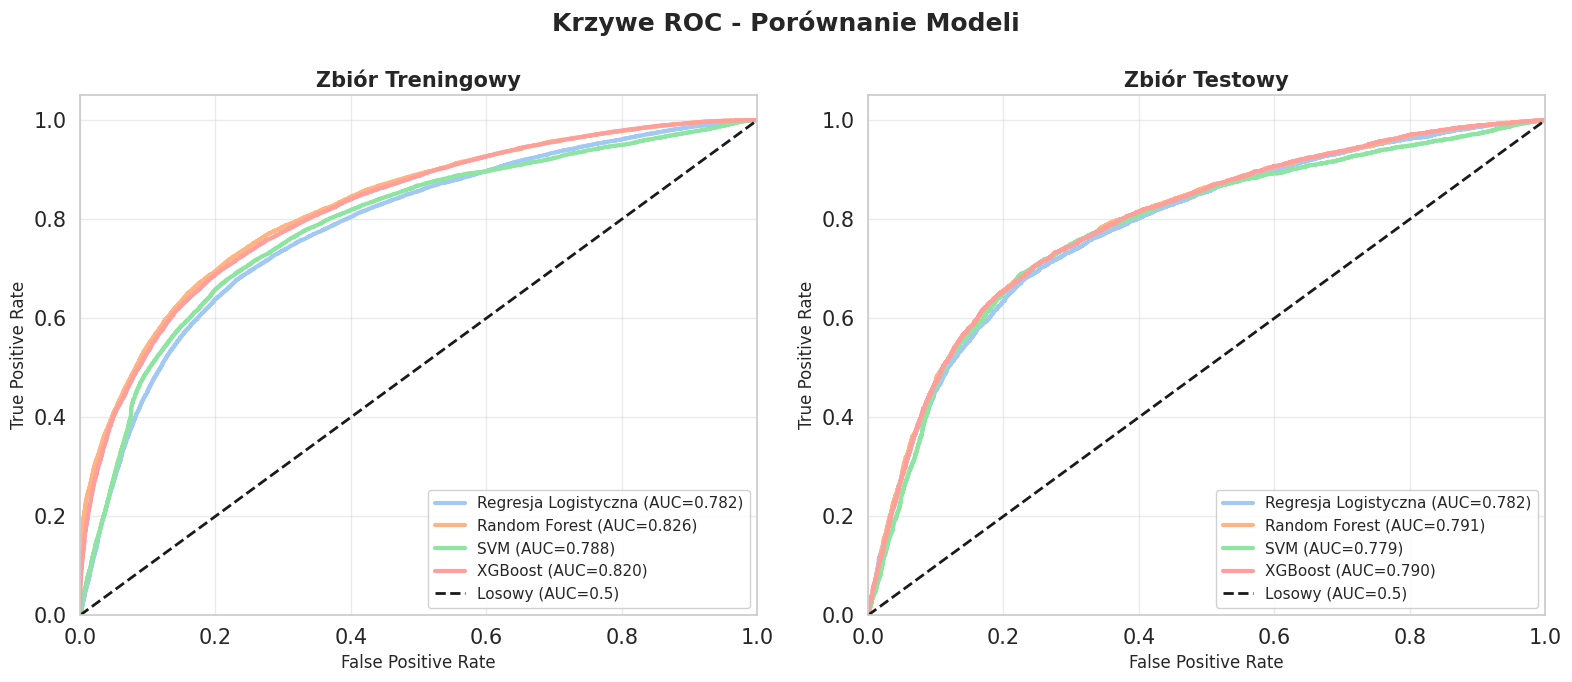

✅ Wykresy ROC zapisane. Dane do tabeli zebrane.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- USTAWIENIA ---
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# --- MODELE ---
models = {
    "Regresja Logistyczna": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=20,
        min_samples_leaf=10, max_features="sqrt", random_state=42
    ),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.8, eval_metric="logloss", random_state=42
    )
}

# --- PRZYGOTOWANIE WYKRESU ROC ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Mniejsza wysokość, bo bez tabeli
ax_train, ax_test = axes

# Zmienna globalna do przechowania wyników dla drugiej części kodu
results_data = []

print("Trwa trenowanie i ewaluacja modeli...")

for name, model in models.items():
    # 1. Trening
    model.fit(X_train_pca, y_train)

    # 2. Obliczenia
    y_train_proba = model.predict_proba(X_train_pca)[:, 1]
    y_test_proba = model.predict_proba(X_test_pca)[:, 1]

    # Metryki do tabeli (zbieramy je tutaj)
    acc_train = accuracy_score(y_train, model.predict(X_train_pca))
    auc_train = roc_auc_score(y_train, y_train_proba)
    acc_test = accuracy_score(y_test, model.predict(X_test_pca))
    auc_test = roc_auc_score(y_test, y_test_proba)

    # Zapisujemy sformatowane wyniki do listy
    results_data.append([
        name,
        f"{acc_train:.4f}", f"{auc_train:.4f}",
        f"{acc_test:.4f}", f"{auc_test:.4f}"
    ])

    # 3. Rysowanie ROC
    fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_proba)
    ax_train.plot(fpr_tr, tpr_tr, lw=3, label=f"{name} (AUC={auc_train:.3f})")

    fpr_te, tpr_te, _ = roc_curve(y_test, y_test_proba)
    ax_test.plot(fpr_te, tpr_te, lw=3, label=f"{name} (AUC={auc_test:.3f})")

# --- STYLIZACJA I ZAPIS ROC ---
titles = ["Zbiór Treningowy", "Zbiór Testowy"]
for ax, title in zip(axes, titles):
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label="Losowy (AUC=0.5)")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11, frameon=True, framealpha=0.9)
    ax.grid(alpha=0.4)

plt.suptitle("Krzywe ROC - Porównanie Modeli", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig("Tylko_Wykresy_ROC.png", dpi=300)
plt.show()
print("✅ Wykresy ROC zapisane. Dane do tabeli zebrane.")

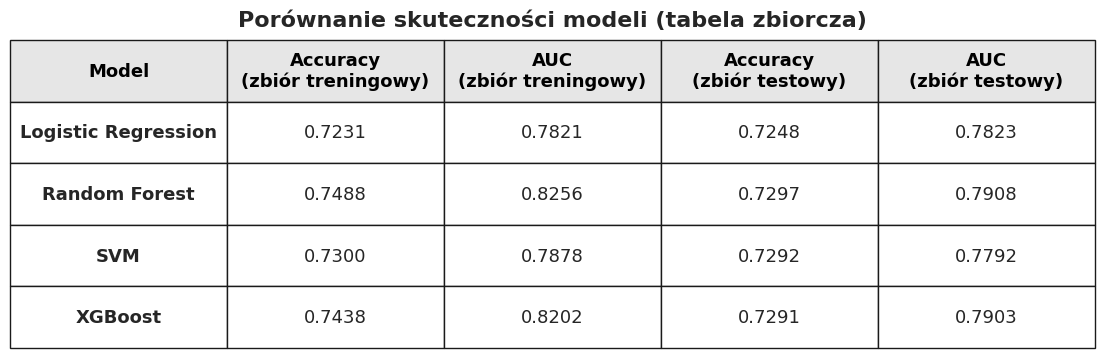

✅ Tabela zapisana: nazwa zmieniona na 'Logistic Regression', tekst mieści się w komórkach.


In [ ]:
import matplotlib.pyplot as plt

# --- 1. POPRAWKA DANYCH I NAGŁÓWKÓW ---
# Podmieniamy nazwę w danych, jeśli występuje polska wersja
for row in results_data:
    if row[0] == "Regresja Logistyczna":
        row[0] = "Logistic Regression"

# Poprawione nagłówki (zbiór zamiast biór) + nawiasy dla estetyki
columns = [
    "Model",
    "Accuracy\n(zbiór treningowy)",
    "AUC\n(zbiór treningowy)",
    "Accuracy\n(zbiór testowy)",
    "AUC\n(zbiór testowy)"
]

# --- 2. KONFIGURACJA FIGURY ---
# Zwiększamy szerokość do 14 cali, żeby tekst się swobodnie mieścił
fig, ax = plt.subplots(figsize=(14, 4))

# Wyłączamy osie
ax.axis('off')

# --- 3. RYSOWANIE TABELI ---
table = ax.table(
    cellText=results_data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# --- 4. STYLIZACJA ---
table.auto_set_font_size(False)
table.set_fontsize(13)  # Rozmiar 13 jest bezpieczny przy tej szerokości
table.scale(1, 2.5)     # Zwiększona wysokość wierszy (2.5), żeby był "oddech"

# Stylizacja nagłówków i pierwszej kolumny
for (row, col), cell in table.get_celld().items():
    # Nagłówki
    if row == 0:
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e6e6e6') # Jasnoszary kolor nagłówka
    # Nazwy modeli (pierwsza kolumna) - opcjonalnie pogrubione
    if col == 0 and row > 0:
        cell.set_text_props(weight='bold')

# --- 5. ZAPIS ---
plt.title("Porównanie skuteczności modeli (tabela zbiorcza)", fontsize=16, fontweight='bold', y=1.02)
plt.savefig("Tylko_Tabela_Wynikow_Poprawiona.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tabela zapisana: nazwa zmieniona na 'Logistic Regression', tekst mieści się w komórkach.")

In [ ]:
#PRACA ujednolicić os y i x (i w tabeli zbiór treningowy zamiast train)

XGBoost jest obecnie najlepszym modelem spośród testowanych, ponieważ osiąga najwyższe AUC na zbiorze testowym (0.793) przy zachowaniu dobrej stabilności.

Random Forest musi zostać uregularyzowany, aby uniknąć poważnego overfittingu.

Regresja logistyczna jest stabilnym modelem bazowym, ale jego potencjał wydajności jest niższy niż modeli zespołowych.

ANALIZA WAŻNOŚCI CECH

🚀 Rozpoczynam obliczanie ważności cech...
   ⏳ Trenuję i analizuję: Regresja Logistyczna...
   ⏳ Trenuję i analizuję: Random Forest...
   ⏳ Trenuję i analizuję: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:56:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ⏳ Trenuję i analizuję: SVM (RBF)...
✅ Obliczenia zakończone.


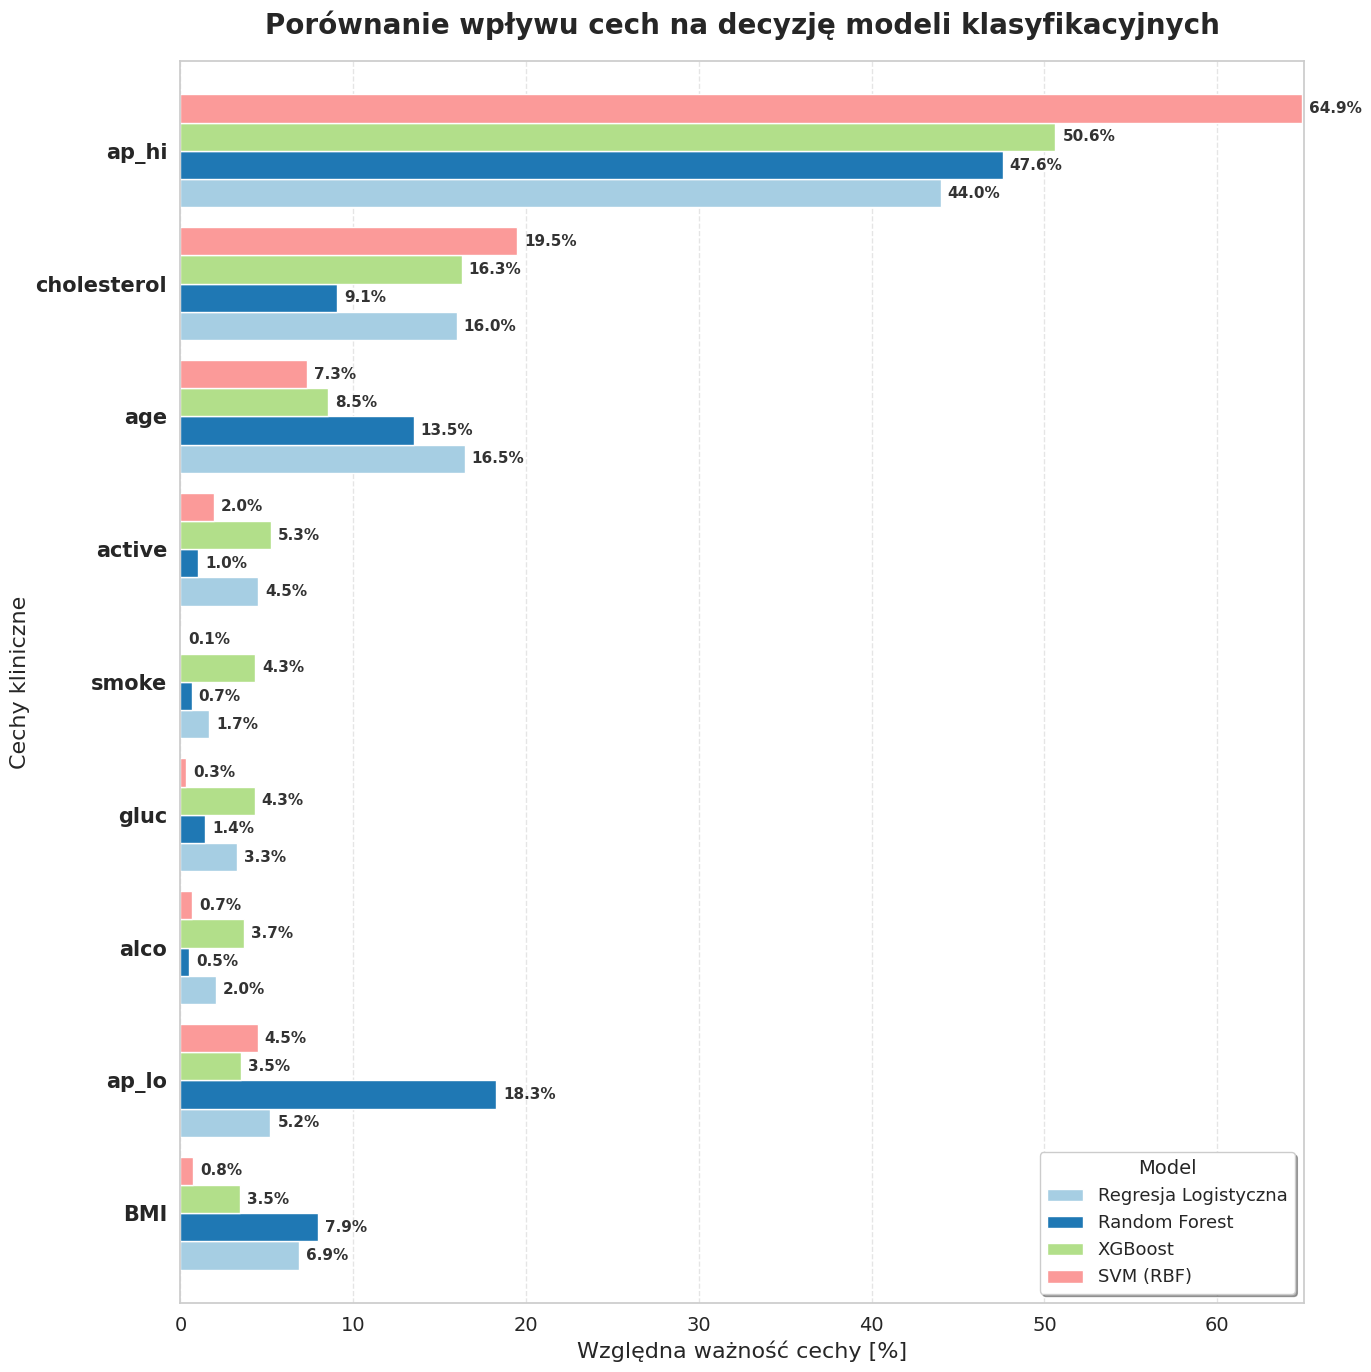

✅ Wykres zapisany jako: Waznosc_Cech_Final_RBF.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

#1. USTAWIENIA ESTETYCZNE
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 2. PRZYGOTOWANIE DANYCH
# Zakładam, że zmienna 'df' jest już wczytana w Twoim notatniku
X = df[['age','BMI','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']]
y = df['cardio']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standaryzacja (kluczowa dla SVM i Regresji)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Zamiana na DataFrame, żeby zachować nazwy kolumn (ważne do wykresu)
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 3. DEFINICJA MODELI
# Tutaj używamy dokładnie takich parametrów, jak w Twojej pracy
models = {
    'Regresja Logistyczna': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    # SVM z jądrem RBF (nieliniowym)
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

# 4. OBLICZANIE WAŻNOŚCI CECH
importances = {}
print("🚀 Rozpoczynam obliczanie ważności cech...")

for name, model in models.items():
    print(f"   ⏳ Trenuję i analizuję: {name}...")
    model.fit(X_train_df, y_train)

    # A) Dla SVM (RBF) -> Używamy Permutation Importance
    if isinstance(model, SVC):
        # Permutacja na zbiorze testowym
        perm_result = permutation_importance(model, X_test_df, y_test, n_repeats=5, random_state=42, n_jobs=-1)
        imp = perm_result.importances_mean
        # Usuwamy ewentualne ujemne wartości (szum)
        imp = [max(0, i) for i in imp]

    # B) Dla Regresji Logistycznej -> Używamy współczynników (weights)
    elif isinstance(model, LogisticRegression):
        imp = abs(model.coef_[0])

    # C) Dla Drzew (Random Forest, XGBoost) -> Używamy wbudowanej ważności (Gini)
    else:
        imp = model.feature_importances_

    # Normalizacja wyników do 100%, aby były porównywalne na jednym wykresie
    importances[name] = pd.Series(imp, index=X.columns)
    importances[name] = importances[name] / importances[name].sum() * 100

print("✅ Obliczenia zakończone.")

# Tworzenie DataFrame z wynikami i sortowanie wg XGBoost
importance_df = pd.DataFrame(importances)
importance_df = importance_df.sort_values(by='XGBoost', ascending=True)

# --- 5. RYSOWANIE WYKRESU ---
# Ustawiamy dużą wysokość (14), żeby grupy cech były rozsunięte
fig, ax = plt.subplots(figsize=(14, 14))

# Paleta kolorów
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#fb9a99']

# Rysowanie słupków (width=0.85 sprawia, że są grube)
importance_df.plot(kind='barh', ax=ax, width=0.85, color=colors, edgecolor='white')

# Opisy i formatowanie
plt.title('Porównanie wpływu cech na decyzję modeli klasyfikacyjnych', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Względna ważność cechy [%]', fontsize=16)
plt.ylabel('Cechy kliniczne', fontsize=16)

# Większe czcionki na osiach
plt.xticks(fontsize=14)
plt.yticks(fontsize=15, fontweight='bold')

# Siatka tylko pionowa
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', visible=False)

# Zakres osi X (zapas na napisy)
plt.xlim(0, 65)

# Dodawanie etykiet procentowych na końcach słupków
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.1f%%',
                 padding=5,
                 fontsize=11,
                 fontweight='bold',
                 color='#333333')

# Legenda
plt.legend(title='Model', title_fontsize=14, fontsize=13, loc='lower right', frameon=True, shadow=True)

plt.tight_layout()

# Zapis do pliku
filename = "Waznosc_Cech_Final_RBF.png"
plt.savefig(filename, dpi=300)
plt.show()

print(f"✅ Wykres zapisany jako: {filename}")

In [ ]:
#PRACA

Modele zgodnie pokazują, że:

CIŚNIENIE SKURCZOWE (AP_HI), CHOLESTEROL i WIEK to najważniejsze czynniki wpływające na wynik klasyfikacji.

Pozostałe cechy (aktywność, spożycie alkoholu, palenie) mają marginalny wpływ — mogą wspomagać model, ale nie dominują.

In [ ]:
import statsmodels.api as sm
# Tworzymy DataFrame z nazwami kolumn po skalowaniu
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=y_train.index)

# Dodanie stałej (interceptu)
X_const = sm.add_constant(X_train_scaled_df)

# Dopasowanie modelu logistycznego
logit_model = sm.Logit(y_train, X_const)
result = logit_model.fit()

# Wyświetlenie raportu
print(result.summary())


*coef - współczynnik regresji — mówi, jak zmiana danej zmiennej wpływa na log-iloraz szans (log-odds) wystąpienia choroby.

*std err - błąd standardowy estymatora — im mniejszy, tym bardziej precyzyjny współczynnik

*z - statystyka testowa (iloraz coef / std err). Im większa wartość bezwzględna, tym silniejszy wpływ zmiennej.

*P>|z| - To jest p-wartość testu statystycznego, który sprawdza czy dany współczynnik (coef) jest istotnie różny od zera:

(P>|z|) < 0.05 → cecha istotnie wpływa na wynik (statystycznie znacząca)

(P>|z|) ≥ 0.05 → brak dowodów, że cecha ma wpływ (nieistotna).

*[0.025, 0.975] - 95% przedział ufności dla współczynnika. Jeśli nie obejmuje zera → zmienna istotna

WNIOSKI:
Wyniki regresji logistycznej wskazują, że wiek, ciśnienie skurczowe i rozkurczowe, BMI oraz poziom cholesterolu mają statystycznie istotny i dodatni wpływ na prawdopodobieństwo wystąpienia chorób serca (p < 0.05).
Natomiast aktywność fizyczna, palenie oraz spożycie alkoholu mają wpływ ujemny, co sugeruje, że czynniki behawioralne mogą częściowo zmniejszać ryzyko, przy czym ich efekt jest słabszy.
Model ma wysoką istotność ogólną — większość zmiennych jest istotna na poziomie p < 0.001.



Ze względu na brak zaobserwowanego wpływu palenia na występowanie chorób układu sercowo-naczyniowego, co stanowi nietypowe zjawisko, przeprowadzono test t-Studenta w celu sprawdzenia, czy zmienne dotyczące palenia i występowania chorób układu sercowo-naczyniowego są od siebie niezależne. Test t-Studenta wykazał, że osoby palące są istotnie młodsze od niepalących (T = −12.67, p < 0.001).Średni wiek palących wynosi ok. 51,8 lat, a niepalących – 52,9 lat.
Różnica ta może częściowo tłumaczyć brak istotnego wpływu palenia na występowanie chorób sercowo-naczyniowych w modelu regresji.

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(df[df['smoke']==1]['age'], df[df['smoke']==0]['age'])
print(f"T = {t_stat:.4f}, p = {p_val:.4f}")

W kolejnym kroku metodą SHAP (SHapley Additive exPlanations), która jest jedną z najnowocześniejszych metod interpretowania modeli ML i szczególnie sprawdza się w przypadku XGBoost oraz Random Forest, wytłumaczymy o ile dana cecha „popycha” predykcję w górę lub w dół względem średniego wyniku modelu.

In [ ]:
import shap

X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer = shap.TreeExplainer(model_xgb) # tree explainer
shap_values = explainer.shap_values(X_test_df)
shap_values
#shap.summary_plot(sh
# ap_values.values, X_test_df)
# na każdym etpie raport klasyfikacyjny, cm i roc auc (dla treningowego i testowego)
# zrobić PCA i ustalić jedne kolory zdrowy/chory
# ocena modeli za pomocą ROC/AUC

ma cecha dodatki wpływ na model - ap_hi
one podaja prawdopodobienstwo przynaleznosci do klasy


Analiza wartości SHAP dla modelu XGBoost pozwala zidentyfikować cechy, które w największym stopniu wpływają na decyzję klasyfikatora. Najbardziej znaczące okazały się: ciśnienie skurczowe (ap_hi), wiek, poziom glukozy oraz ciśnienie rozkurczowe (ap_lo). Wysokie wartości tych parametrów zwiększają przewidywane ryzyko chorób sercowo-naczyniowych, natomiast wartości niskie je obniżają.

Cechy takie jak BMI, cholesterol, palenie papierosów, spożycie alkoholu i aktywność fizyczna również wpływają na wynik predykcji, jednak ich udział jest mniejszy. Wyniki te są spójne z wiedzą kliniczną i potwierdzają, że model prawidłowo identyfikuje najważniejsze czynniki ryzyka chorób układu krążenia.